# AkShare 股票数据接口教程

> 基于本项目锁定的 AkShare 版本，按投资研究语义组织为 **8 个稳定领域**。
>
> 本 Lab 只学习 `ak.<接口函数>(...)` 的原始调用、参数和返回值，不在这里增加二次封装。
>
> 官方文档：https://akshare.akfamily.xyz/data/stock/stock.html

In [1]:
# === 环境初始化（必须最先运行）===
# AKShare 的部分接口会使用 tqdm.notebook，需要 ipywidgets 提供 IProgress。
try:
    import ipywidgets
except ImportError as exc:
    raise RuntimeError(
        "当前内核缺少 ipywidgets。请在仓库根目录运行 "
        "`uv sync --project labs`，然后重启内核。"
    ) from exc

print(f"环境初始化完成（ipywidgets {ipywidgets.__version__}）")

环境初始化完成（ipywidgets 8.1.8）


---
## 0. 概述

### 学习目标

理解 AKShare 股票接口的函数名、参数、返回字段与上游数据源；用小型、可独立运行的代码单元验证接口，不构建新的数据适配层。

### 安装与验证

```bash
uv sync --project labs
uv run --project labs jupyter lab labs
```

In [2]:
%matplotlib inline
import pandas as pd
import akshare as ak
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
import mplfinance as mpf

# pandas 3 默认优先使用 pyarrow 字符串；AKShare 1.18.78 的部分正则
# （例如 新闻字段 中的 \\u3000）需要 Python 正则引擎。
pd.options.mode.string_storage = "python"

print('AkShare 版本:', ak.__version__)
print('可用接口数量:', len(dir(ak)))

CHINESE_FONT_CANDIDATES = [
    "Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC",
    "PingFang SC", "Hiragino Sans GB", "WenQuanYi Micro Hei", "Arial Unicode MS",
]
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
CHINESE_FONT = next(
    (name for name in CHINESE_FONT_CANDIDATES if name in installed_fonts),
    None,
)
if CHINESE_FONT is None:
    raise RuntimeError(
        "未找到可显示中文的字体，请安装 Microsoft YaHei、SimHei 或 Noto Sans CJK SC。"
    )

matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [CHINESE_FONT],
    "axes.unicode_minus": False,
    "font.weight": "normal",
})
MPL_CHINESE_STYLE = mpf.make_mpf_style(
    base_mpf_style="yahoo",
    rc={
        "font.family": "Microsoft YaHei",
        "font.sans-serif": ["Microsoft YaHei"],
        "axes.unicode_minus": False,
    },
)
print("Matplotlib 中文字体:", CHINESE_FONT)

AkShare 版本: 1.18.82
可用接口数量: 1149
Matplotlib 中文字体: Microsoft YaHei


### 核心约定

| 参数 | 含义 | 常见取值 |
| --- | --- | --- |
| `symbol` | 标的代码 | 东财 `'600000'`、新浪 `'sh600000'`、雪球 `'SH600000'` |
| `date` | 日期 | `'20241108'`（YYYYMMDD 字符串） |
| `period` | 周期 | `'daily'` / `'weekly'` / `'monthly'` |
| `adjust` | 复权 | `''` 不复权、`'qfq'` 前复权、`'hfq'` 后复权 |


---
## 1. `universe`：证券主数据与股票池

回答“市场里有哪些股票”。用于证券主数据、上市状态。

**本教程收录的当前可用接口：7 个**

### 可用接口汇总

| 序号 | 子类   | 接口名称        | 接口函数                      | 数据源     |
| -: | ---- | ----------- | ------------------------- | ------- |
|  1 | 基础名单 | 沪深京A股股票列表   | `stock_info_a_code_name`  | —       |
|  2 | 基础名单 | 沪市股票列表      | `stock_info_sh_name_code` | 上海证券交易所 |
|  3 | 基础名单 | 深市股票列表      | `stock_info_sz_name_code` | 深证证券交易所 |
|  4 | 基础名单 | A+H股列表-腾讯   | `stock_zh_ah_name`        | 腾讯财经    |
|  5 | 上市状态 | 沪市暂停/终止上市名单 | `stock_info_sh_delist`    | 上海证券交易所 |
|  6 | 上市状态 | 深市暂停/终止上市名单 | `stock_info_sz_delist`    | 深圳证券交易所 |
|  7 | 上市状态 | 股票曾用名-新浪    | `stock_info_change_name`  | 新浪财经    |


### A股列表

In [3]:
# 全 A 股代码与简称列表
try:
    df_a = ak.stock_info_a_code_name()
    print("全 A 股数量：", len(df_a))
    display(df_a.head())
except Exception as exc:
    print("全 A 股代码与简称列表接口当前不可用：", type(exc).__name__, str(exc))
    print("继续使用上交所、深交所或腾讯A+H列表接口完成后续实验。")

  0%|          | 0/17 [00:00<?, ?it/s]

全 A 股数量： 5548


,code,name
0,000001,平安银行
1,000002,万 科Ａ
2,000006,深振业Ａ
3,000007,全新好
4,000008,神州高铁


In [4]:
df = ak.stock_info_sh_name_code()
print('沪市股票数量:', len(df))
df.head()

沪市股票数量: 1699


,证券代码,证券简称,证券全称,公司简称,公司全称,上市日期
0,600000,浦发银行,浦发银行,浦发银行,上海浦东发展银行股份有限公司,1999-11-10
1,600004,白云机场,白云机场,白云机场,广州白云国际机场股份有限公司,2003-04-28
2,600006,东风股份,东风股份,东风股份,东风汽车股份有限公司,1999-07-27
3,600007,中国国贸,中国国贸,中国国贸,中国国际贸易中心股份有限公司,1999-03-12
4,600008,首创环保,首创环保,首创环保,北京首创生态环保集团股份有限公司,2000-04-27


In [5]:
# 深市交易所
try:
    df = ak.stock_info_sz_name_code(symbol="A股列表")
    print('深市股票数量:', len(df))
    display(df.head())
except Exception as exc:
    print("深市股票代码与简称列表接口当前不可用：", type(exc).__name__, str(exc))

深市股票数量: 2897


,板块,A股代码,A股简称,A股上市日期,A股总股本,A股流通股本,所属行业
0,主板,000001,平安银行,1991-04-03,"19,405,918,198","19,405,684,991",J 金融业
1,主板,000002,万 科Ａ,1991-01-29,"9,724,196,533","9,716,961,890",K 房地产
2,主板,000006,深振业Ａ,1992-04-27,"1,349,995,046","1,349,995,046",K 房地产
3,主板,000007,全新好,1992-04-13,"346,448,044","346,448,044",K 房地产
4,主板,000008,神州高铁,1992-05-07,"2,716,377,683","2,716,296,952",C 制造业


In [6]:
df = ak.stock_zh_ah_name()
print('A+H股票数量:', len(df))
df.head()

  0%|          | 0/11 [00:00<?, ?it/s]

A+H股票数量: 220


,代码,名称
0,00525,广深铁路股份
1,03678,弘业期货
2,02238,广汽集团
3,02068,中铝国际
4,00323,马鞍山钢铁股份


### 终止/暂停上市名单

In [7]:
df = ak.stock_info_sh_delist()
print('沪市暂停/终止股票数量:', len(df))
df.head()

沪市暂停/终止股票数量: 159


,公司代码,公司简称,上市日期,暂停上市日期
0,600001,邯郸钢铁,1998-01-22,2009-12-29
1,600002,齐鲁退市,1998-04-08,2006-04-24
2,600003,ST东北高,1999-08-10,2010-02-26
3,600005,武钢股份,1999-08-03,2017-02-14
4,600065,*ST联 谊,1997-05-23,2007-12-13


In [8]:
try:
    df = ak.stock_info_sz_delist()
    print('深市暂停/终止股票数量:', len(df))
    display(df.head())
except Exception as exc:
    print("深市暂停/终止股票列表接口当前不可用：", type(exc).__name__, str(exc))

深市暂停/终止股票数量: 208


,证券代码,证券简称,上市日期,终止上市日期
0,000003,PT金田Ａ,1991-01-14,2002-06-14
1,000004,国华退,1990-12-01,2026-07-14
2,000005,ST星源,1990-12-10,2024-04-26
3,000013,*ST石化A,1992-05-06,2004-09-20
4,000015,PT中浩Ａ,1992-06-25,2001-10-25


### 股票曾用名

In [9]:
stock_info_change_name_list = ak.stock_info_change_name(symbol="000002")
print(stock_info_change_name_list)

   index      name
0      1  万科A(万科B)
1      2      G万科A
2      3       万科A


---
## 2. `market`：行情与估值快照

回答“股票现在多少钱，过去怎么走，目前贵不贵，能不能交易？”。

涵盖市场总貌；实时行情；日线、周线、月线；分钟行情；逐笔成交；盘口；PE、PB、股息率；停复牌。

**本教程收录的当前可用接口：42 个**

### 可用接口汇总

| 序号 | 子类    | 接口名称          | 接口函数                           | 数据源     |
| -: | ----- | ------------- | ------------------------------ | ------- |
|  1 | 市场总貌  | 每日股票成交概况-上交所  | `stock_sse_deal_daily`         | 上海证券交易所 |
|  2 | 市场总貌  | 市场总貌-上交所      | `stock_sse_summary`            | 上海证券交易所 |
|  3 | 实时行情  | A股实时行情-新浪     | `stock_zh_a_spot`              | 新浪财经    |
|  4 | 实时行情  | A股实时行情-腾讯     | `stock_zh_a_spot_tx`           | 腾讯财经    |
|  5 | 实时行情  | 科创板实时行情-新浪    | `stock_zh_kcb_spot`            | 新浪财经    |
|  6 | 实时行情  | A股指数实时行情-新浪   | `stock_zh_index_spot_sina`     | 新浪财经    |
|  7 | 实时行情  | 港股指数实时行情-新浪   | `stock_hk_index_spot_sina`     | 新浪财经    |
|  8 | 实时行情  | B股实时行情-新浪     | `stock_zh_b_spot`              | 新浪财经    |
|  9 | 实时行情  | A+H股实时行情-腾讯   | `stock_zh_ah_spot`             | 腾讯财经    |
| 10 | 实时行情  | 次新股实时行情-新浪    | `stock_zh_a_new`               | 新浪财经    |
| 11 | 历史行情  | A股历史日线-新浪     | `stock_zh_a_daily`             | 新浪财经    |
| 12 | 历史行情  | A股历史日线-腾讯     | `stock_zh_a_hist_tx`           | 腾讯财经    |
| 13 | 历史行情  | A股指数历史日线      | `stock_zh_index_daily`         | 未识别     |
| 14 | 历史行情  | A股指数历史日线-腾讯   | `stock_zh_index_daily_tx`      | 腾讯财经    |
| 15 | 历史行情  | 中证指数历史日线      | `stock_zh_index_hist_csindex`  | 未识别     |
| 16 | 历史行情  | 科创板历史日线-新浪    | `stock_zh_kcb_daily`           | 新浪财经    |
| 17 | 历史行情  | 科创板CDR历史日线-新浪 | `stock_zh_a_cdr_daily`         | 新浪财经    |
| 18 | 历史行情  | 港股历史日线-新浪     | `stock_hk_daily`               | 新浪财经    |
| 19 | 历史行情  | 港股指数历史日线-新浪   | `stock_hk_index_daily_sina`    | 新浪财经    |
| 20 | 历史行情  | 美股历史日线-新浪     | `stock_us_daily`               | 新浪财经    |
| 21 | 历史行情  | B股历史日线-新浪     | `stock_zh_b_daily`             | 新浪财经    |
| 22 | 历史行情  | A+H股历史日线-腾讯   | `stock_zh_ah_daily`            | 腾讯财经    |
| 23 | 分时与逐笔 | 日内分时-新浪       | `stock_intraday_sina`          | 新浪财经    |
| 24 | 分时与逐笔 | A股分钟行情-新浪     | `stock_zh_a_minute`            | 新浪财经    |
| 25 | 分时与逐笔 | B股分钟行情-新浪     | `stock_zh_b_minute`            | 新浪财经    |
| 26 | 分时与逐笔 | A股逐笔成交-腾讯     | `stock_zh_a_tick_tx_js`        | 腾讯财经    |
| 27 | 估值指标  | 个股估值分析-东方财富   | `stock_value_em`               | 东方财富    |
| 28 | 估值指标  | 中证指数估值        | `stock_zh_index_value_csindex` | 未识别     |
| 29 | 估值指标  | A股股息率-乐咕      | `stock_a_gxl_lg`               | 乐咕乐股    |
| 30 | 估值指标  | A股市净率中位数-乐咕   | `stock_a_all_pb`               | 乐咕乐股    |
| 31 | 估值指标  | A股市盈率中位数-乐咕   | `stock_a_ttm_lyr`              | 乐咕乐股    |
| 32 | 估值指标  | 主板市净率-乐咕      | `stock_market_pb_lg`           | 乐咕乐股    |
| 33 | 估值指标  | 主板市盈率-乐咕      | `stock_market_pe_lg`           | 乐咕乐股    |
| 34 | 估值指标  | 指数市净率-乐咕      | `stock_index_pb_lg`            | 乐咕乐股    |
| 35 | 估值指标  | 指数市盈率-乐咕      | `stock_index_pe_lg`            | 乐咕乐股    |
| 36 | 估值指标  | 巴菲特指标-乐咕      | `stock_buffett_index_lg`       | 乐咕乐股    |
| 37 | 估值指标  | 股债利差-乐咕       | `stock_ebs_lg`                 | 乐咕乐股    |
| 38 | 估值指标  | 恒生指数股息率-乐咕    | `stock_hk_gxl_lg`              | 乐咕乐股    |
| 39 | 估值指标  | 港股估值与ROE指标-亿牛 | `stock_hk_indicator_eniu`      | 亿牛网     |
| 40 | 估值指标  | 港股估值指标-百度     | `stock_hk_valuation_baidu`     | 百度股市通   |
| 41 | 估值指标  | A股估值指标-百度     | `stock_zh_valuation_baidu`     | 百度股市通   |
| 42 | 交易状态  | 停复牌信息-东方财富    | `stock_tfp_em`                 | 东方财富    |


### 市场总貌

In [10]:
df = ak.stock_sse_deal_daily()
print('每日股票成交概况-上交所:')
df

每日股票成交概况-上交所:


,单日情况,股票,主板A,主板B,科创板,股票回购
0,挂牌数,2316.0000,1692.0000,43.0000,581.0000,0.00
1,市价总值,529411.2000,463338.6800,1008.8600,65063.6600,0.00
2,流通市值,496863.9200,447044.9900,752.0800,49066.8500,0.00
3,成交金额,6759.4600,5653.1900,2.0000,1104.2700,4.45
4,成交量,626.1200,594.5500,0.5000,31.0700,1.19
5,平均市盈率,14.3300,13.3500,7.6200,42.0400,NaN
6,换手率,1.2768,1.2201,0.1979,1.6972,0.00
7,流通换手率,1.3604,1.2646,0.2655,2.2506,0.00


In [11]:
df = ak.stock_sse_summary()
print('市场总貌-上交所:')
df

市场总貌-上交所:


,项目,股票,主板,科创板
0,流通股本,48613.39,46393.29,2220.11
1,总市值,691949.76,518289.32,173660.44
2,平均市盈率,17.20,13.74,124.61
3,上市公司,2317,1702,615
4,上市股票,2355,1740,615
5,流通市值,610144.54,498563.5,111581.04
6,报告时间,20260819,20260819,20260819
8,总股本,51776.13,48553.08,3223.04


### 实时行情
- A股
- 港股
- 指数

#### A股

In [12]:
# 1. A股实时行情（新浪）
df_sina = ak.stock_zh_a_spot()

print('A股实时行情:', df_sina.shape)

df_sina.tail(5)

Please wait for a moment:   0%|          | 0/70 [00:00<?, ?it/s]

A股实时行情: (5547, 14)


,代码,名称,最新价,涨跌额,涨跌幅,买入,卖出,昨收,今开,最高,最低,成交量,成交额,时间戳
5542,sz301687,新广益,50.10,0.80,1.623,50.05,50.10,49.30,50.29,50.46,49.18,1108940.0,5.529197e+07,11:04:45
5543,sz301696,三瑞智能,100.00,-0.75,-0.744,100.01,100.26,100.75,102.00,102.75,98.18,1469137.0,1.465374e+08,11:04:39
5544,sz301707,展芯股份,79.37,-6.73,-7.816,79.36,79.37,86.10,83.58,83.97,77.70,5264781.0,4.193870e+08,11:04:42
5545,sz301717,超纯应材,382.55,-0.45,-0.117,382.55,382.60,383.00,383.00,390.90,355.60,3625334.0,1.350978e+09,11:04:45
5546,sz302132,中航成飞,57.35,0.33,0.579,57.36,57.39,57.02,57.40,58.27,57.05,2733153.0,1.576539e+08,11:04:39


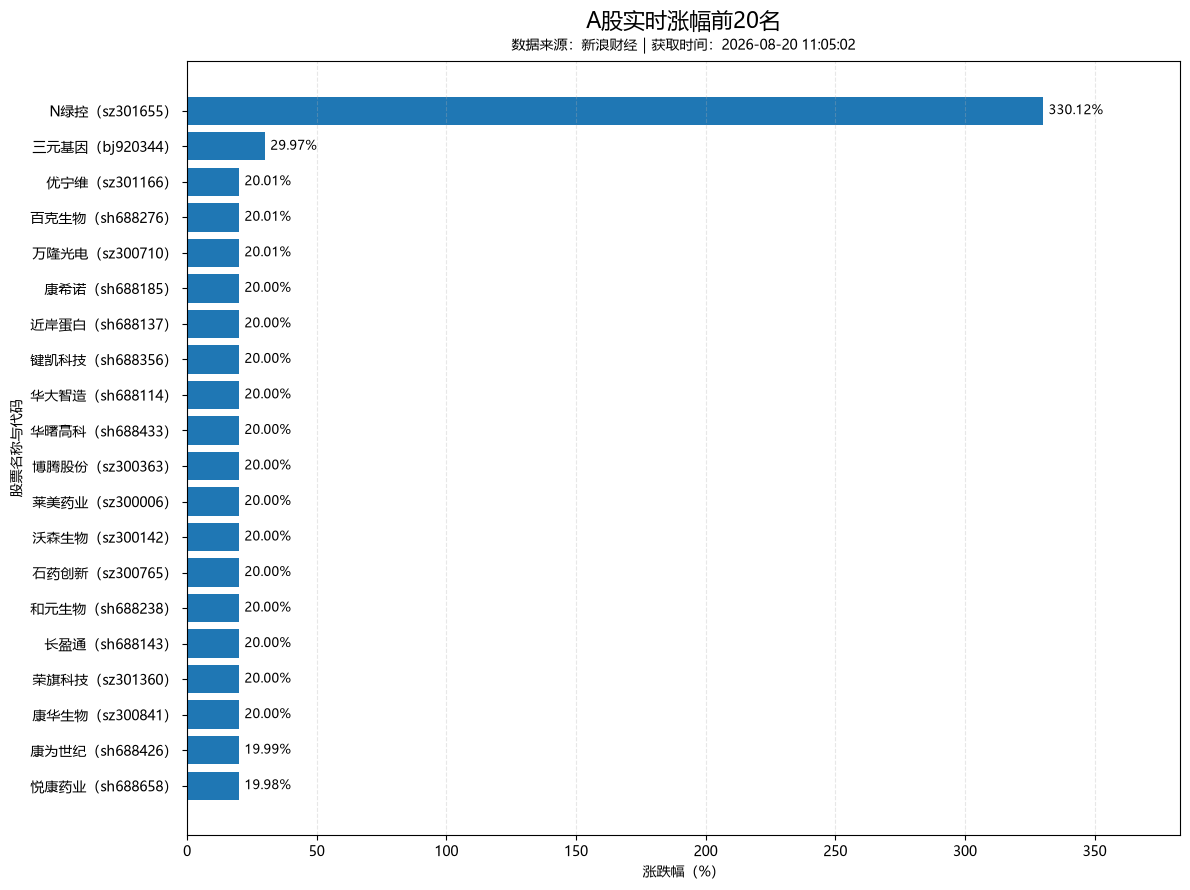

In [13]:
plot_sina = df_sina[["代码", "名称", "涨跌幅"]].copy()

plot_sina["涨跌幅"] = pd.to_numeric(
    plot_sina["涨跌幅"],
    errors="coerce",
)

plot_sina = plot_sina.dropna(
    subset=["名称", "涨跌幅"],
)

# 股票名称同时显示代码
plot_sina["股票"] = (
    plot_sina["名称"].astype(str)
    + "（"
    + plot_sina["代码"].astype(str)
    + "）"
)

# 4. 获取涨幅最高的20只股票
top20_sina = (
    plot_sina
    .nlargest(20, "涨跌幅")
    .sort_values("涨跌幅")
)

# 5. 绘制横向柱状图
fig, ax = plt.subplots(figsize=(12, 9))

bars = ax.barh(
    top20_sina["股票"],
    top20_sina["涨跌幅"],
)

# 6. 在柱形末端显示涨跌幅标签
ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in top20_sina["涨跌幅"]
    ],
    padding=4,
    fontsize=9,
)

# 7. 设置标题和坐标轴
ax.set_title(
    "A股实时涨幅前20名",
    fontsize=16,
    pad=24,
)

ax.text(
    0.5,
    1.01,
    f"数据来源：新浪财经｜获取时间：{pd.Timestamp.now():%Y-%m-%d %H:%M:%S}",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
)

ax.set_xlabel("涨跌幅（%）")
ax.set_ylabel("股票名称与代码")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3,
)

# 为柱形末端标签留出空间
max_value = top20_sina["涨跌幅"].max()
min_value = top20_sina["涨跌幅"].min()

ax.set_xlim(
    left=min(0, min_value),
    right=max_value * 1.16,
)

plt.tight_layout()
plt.show()

In [14]:
# 2. A股实时行情（腾讯）
df_tx = ak.stock_zh_a_spot_tx()

print('A股实时行情:', df_tx.shape)

df_tx.tail(5)

  0%|          | 0/27 [00:00<?, ?it/s]

A股实时行情: (5545, 28)


,code,hsl,lb,ltsz,name,pe_ttm,pn,speed,state,stock_type,...,zdf_w52,zdf_y,zf,zljlr,zllc,zllc_d5,zllr,zllr_d5,zsz,zxj
5540,sz002155,0.00,0.00,383.75,湖南黄金,21.92,4.66,0.00,S,GP-A,...,26.79,18.13,0.00,0.00,0.00,0.00,0.00,0.00,383.79,24.56
5541,sz300176,0.00,0.00,20.25,鸿特科技,42.09,2.08,0.00,S,GP-A-CYB,...,-30.82,-21.35,0.00,0.00,0.00,0.00,0.00,0.00,20.25,5.23
5542,sh600984,0.00,0.00,56.44,建设机械,-2.53,3.16,0.00,S,GP-A,...,22.68,9.78,0.00,0.00,0.00,0.00,0.00,0.00,56.44,4.49
5543,sz002084,0.00,0.00,23.14,海鸥住工,-17.24,1.79,0.00,S,GP-A,...,-1.37,-7.47,0.00,0.00,0.00,0.00,0.00,0.00,23.19,3.59
5544,sz002445,0.00,0.00,72.41,中南文化,164.29,3.18,0.00,S,GP-A,...,17.24,17.69,0.00,0.00,0.00,0.00,0.00,0.00,72.72,3.06


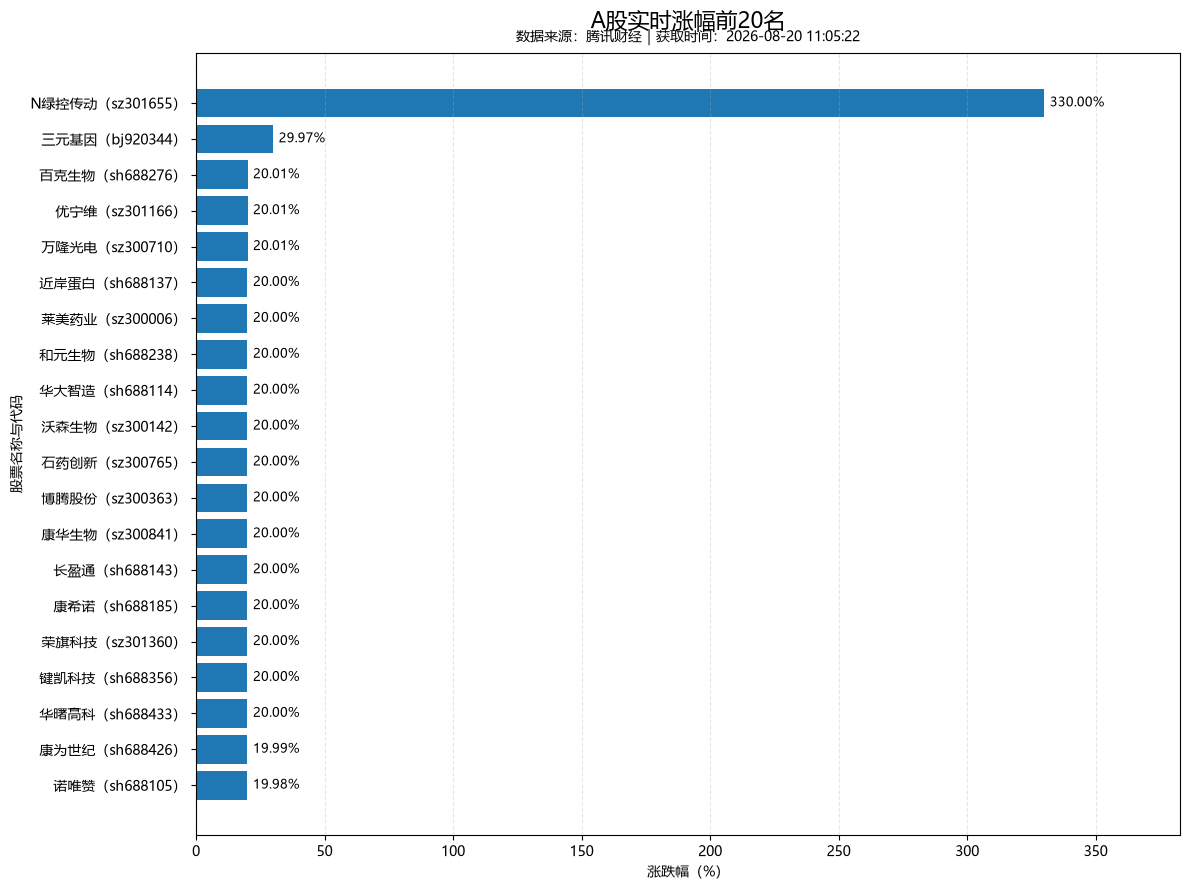

In [15]:
plot_tx = df_tx[["code", "name", "zdf"]].copy()

plot_tx["zdf"] = pd.to_numeric(
    plot_tx["zdf"],
    errors="coerce",
)

plot_tx = plot_tx.dropna(
    subset=["name", "zdf"],
)

# 股票名称同时显示代码
plot_tx["股票"] = (
    plot_tx["name"].astype(str)
    + "（"
    + plot_tx["code"].astype(str)
    + "）"
)

# 4. 取涨幅最高的20只
top20_tx = (
    plot_tx
    .nlargest(20, "zdf")
    .sort_values("zdf")
)

# 5. 绘图
fig, ax = plt.subplots(figsize=(12, 9))

bars = ax.barh(
    top20_tx["股票"],
    top20_tx["zdf"],
)

# 6. 给每根柱子增加数值标签
ax.bar_label(
    bars,
    labels=[f"{value:.2f}%" for value in top20_tx["zdf"]],
    padding=4,
    fontsize=9,
)

ax.set_title(
    "A股实时涨幅前20名",
    fontsize=16,
    pad=18,
)

# 副标题：注明数据来源和获取时间
ax.text(
    0.5,
    1.01,
    f"数据来源：腾讯财经｜获取时间：{pd.Timestamp.now():%Y-%m-%d %H:%M:%S}",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
)

ax.set_xlabel("涨跌幅（%）")
ax.set_ylabel("股票名称与代码")
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3,
)

# 为最右侧标签留出空间
max_value = top20_tx["zdf"].max()
ax.set_xlim(
    left=min(0, top20_tx["zdf"].min()),
    right=max_value * 1.16,
)

plt.tight_layout()
plt.show()

In [16]:
# ============================================
# 新浪 vs 腾讯 A股实时行情接口比较
# ============================================

import pandas as pd


# ------------------------------------------------
# 1. 基本信息比较
# ------------------------------------------------

print("=== 1. 接口基本信息 ===")

print(f"新浪: {df_sina.shape[0]} 行 × {df_sina.shape[1]} 列")
print(f"腾讯: {df_tx.shape[0]} 行 × {df_tx.shape[1]} 列")

print("\n新浪字段:")
print(df_sina.columns.tolist())

print("\n腾讯字段:")
print(df_tx.columns.tolist())


# ------------------------------------------------
# 2. 统一股票代码和名称
# ------------------------------------------------

sina = df_sina.copy()
tx = df_tx.copy()

# 新浪
sina["统一代码"] = (
    sina["代码"]
    .astype(str)
    .str.lower()
    .str.strip()
)

sina["统一名称"] = sina["名称"].astype(str).str.strip()

# 腾讯
tx["统一代码"] = (
    tx["code"]
    .astype(str)
    .str.lower()
    .str.strip()
)

tx["统一名称"] = tx["name"].astype(str).str.strip()


# ------------------------------------------------
# 3. 股票覆盖范围比较
# ------------------------------------------------

sina_codes = set(sina["统一代码"])
tx_codes = set(tx["统一代码"])

common_codes = sina_codes & tx_codes
only_sina = sina_codes - tx_codes
only_tx = tx_codes - sina_codes

print("\n=== 2. 股票覆盖范围 ===")

print("新浪股票数:", len(sina_codes))
print("腾讯股票数:", len(tx_codes))
print("共同股票数:", len(common_codes))
print("仅新浪存在:", len(only_sina))
print("仅腾讯存在:", len(only_tx))

coverage = pd.DataFrame({
    "指标": [
        "新浪股票数",
        "腾讯股票数",
        "共同股票数",
        "仅新浪存在",
        "仅腾讯存在",
    ],
    "数量": [
        len(sina_codes),
        len(tx_codes),
        len(common_codes),
        len(only_sina),
        len(only_tx),
    ],
})

display(coverage)


# ------------------------------------------------
# 4. 查看两个数据源中缺失的股票
# ------------------------------------------------

print("\n=== 3. 新浪有、腾讯没有 ===")

only_sina_df = (
    sina[sina["统一代码"].isin(only_sina)]
    [["统一代码", "统一名称"]]
    .sort_values("统一代码")
)

display(only_sina_df.head(20))


print("\n=== 4. 腾讯有、新浪没有 ===")

only_tx_df = (
    tx[tx["统一代码"].isin(only_tx)]
    [["统一代码", "统一名称"]]
    .sort_values("统一代码")
)

display(only_tx_df.head(20))


# ------------------------------------------------
# 5. 合并共同股票
# ------------------------------------------------

comparison = (
    sina[
        [
            "统一代码",
            "统一名称",
            "最新价",
            "涨跌额",
            "涨跌幅",
            "昨收",
            "今开",
            "最高",
            "最低",
            "成交量",
            "成交额",
            "时间戳",
        ]
    ]
    .merge(
        tx,
        on="统一代码",
        how="inner",
        suffixes=("_新浪", "_腾讯"),
    )
)

print("\n=== 5. 合并后的共同股票 ===")
print("共同股票:", comparison.shape[0])

display(
    comparison[
        [
            "统一代码",
            "统一名称_新浪",
            "统一名称_腾讯",
            "最新价",
            "涨跌幅",
            "时间戳",
        ]
    ].head(10)
)


# ------------------------------------------------
# 6. 股票名称一致性检查
# ------------------------------------------------

comparison["名称是否一致"] = (
    comparison["统一名称_新浪"]
    == comparison["统一名称_腾讯"]
)

name_diff = comparison.loc[
    ~comparison["名称是否一致"],
    [
        "统一代码",
        "统一名称_新浪",
        "统一名称_腾讯",
    ],
]

print("\n=== 6. 股票名称一致性 ===")
print(
    "名称一致率:",
    f"{comparison['名称是否一致'].mean():.2%}"
)

print("名称不同股票数:", len(name_diff))

display(name_diff.head(20))


# ------------------------------------------------
# 7. 字段结构差异
# ------------------------------------------------

print("\n=== 7. 字段结构比较 ===")

field_compare = pd.DataFrame({
    "新浪字段": pd.Series(df_sina.columns.tolist()),
    "腾讯字段": pd.Series(df_tx.columns.tolist()),
})

display(field_compare)


# ------------------------------------------------
# 8. 数据完整度比较
# ------------------------------------------------

sina_missing = (
    df_sina.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("新浪缺失率")
)

tx_missing = (
    df_tx.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("腾讯缺失率")
)

print("\n新浪字段缺失率:")
display(sina_missing.to_frame())

print("\n腾讯字段缺失率:")
display(tx_missing.to_frame())


# ------------------------------------------------
# 9. 汇总结论
# ------------------------------------------------

summary = pd.DataFrame({
    "比较项": [
        "股票数量",
        "字段数量",
        "共同股票",
        "独有股票",
        "字段可读性",
    ],
    "新浪": [
        len(sina),
        df_sina.shape[1],
        len(common_codes),
        len(only_sina),
        "中文标准字段",
    ],
    "腾讯": [
        len(tx),
        df_tx.shape[1],
        len(common_codes),
        len(only_tx),
        "腾讯原始字段",
    ],
})

print("\n=== 新浪 vs 腾讯实时行情接口总结 ===")
display(summary)

=== 1. 接口基本信息 ===
新浪: 5547 行 × 14 列
腾讯: 5545 行 × 28 列

新浪字段:
['代码', '名称', '最新价', '涨跌额', '涨跌幅', '买入', '卖出', '昨收', '今开', '最高', '最低', '成交量', '成交额', '时间戳']

腾讯字段:
['code', 'hsl', 'lb', 'ltsz', 'name', 'pe_ttm', 'pn', 'speed', 'state', 'stock_type', 'turnover', 'volume', 'zd', 'zdf', 'zdf_d10', 'zdf_d20', 'zdf_d5', 'zdf_d60', 'zdf_w52', 'zdf_y', 'zf', 'zljlr', 'zllc', 'zllc_d5', 'zllr', 'zllr_d5', 'zsz', 'zxj']

=== 2. 股票覆盖范围 ===
新浪股票数: 5547
腾讯股票数: 5545
共同股票数: 5544
仅新浪存在: 3
仅腾讯存在: 1


,指标,数量
0,新浪股票数,5547
1,腾讯股票数,5545
2,共同股票数,5544
3,仅新浪存在,3
4,仅腾讯存在,1



=== 3. 新浪有、腾讯没有 ===


,统一代码,统一名称
2698,sz000089,深圳机场
2797,sz000576,甘化科工
4518,sz300413,芒果超媒



=== 4. 腾讯有、新浪没有 ===


...

,新浪缺失率
代码,0.0
名称,0.0
最新价,0.0
涨跌额,0.0
涨跌幅,0.0
买入,0.0
卖出,0.0
昨收,0.0
今开,0.0
最高,0.0



腾讯字段缺失率:


,腾讯缺失率
code,0.0
hsl,0.0
lb,0.0
ltsz,0.0
name,0.0
pe_ttm,0.0
pn,0.0
speed,0.0
state,0.0
stock_type,0.0



=== 新浪 vs 腾讯实时行情接口总结 ===


,比较项,新浪,腾讯
0,股票数量,5547,5545
1,字段数量,14,28
2,共同股票,5544,5544
3,独有股票,3,1
4,字段可读性,中文标准字段,腾讯原始字段


#### 指数

In [17]:
df = ak.stock_zh_index_spot_sina()

print('A股指数实时行情:', df.shape)

df.head(5)

  0%|          | 0/8 [00:00<?, ?it/s]

A股指数实时行情: (562, 11)


,代码,名称,最新价,涨跌额,涨跌幅,昨收,今开,最高,最低,成交量,成交额
0,sh000001,上证指数,3905.4199,10.997,0.282,3894.4224,3907.2058,3925.0615,3899.2937,303124392,623863712118
1,sh000002,Ａ股指数,4094.8212,11.544,0.283,4083.2772,4096.7122,4115.4261,4088.3812,302956787,623599936873
2,sh000003,Ｂ股指数,281.2458,0.619,0.221,280.6263,280.6342,281.6325,280.6342,117051,39295898
3,sh000004,工业指数,3711.9933,21.141,0.573,3690.8520,3716.7996,3739.1149,3703.6639,199408455,521744093213
4,sh000005,商业指数,2576.6415,3.636,0.141,2573.0052,2572.9102,2586.4606,2570.5819,18468390,20996440146


In [18]:
df = ak.stock_hk_index_spot_sina()

print('港股指数实时行情:', df.shape)

df.head(5)

港股指数实时行情: (38, 9)


,代码,名称,最新价,涨跌额,涨跌幅,昨收,今开,最高,最低
0,CES100,中华港股通精选100指数,5465.975,41.841,0.771,5424.134,5490.003,5496.580,5459.176
1,CES120,中华120指数,6500.754,18.599,0.287,6482.156,6531.637,6542.531,6493.343
2,CES280,中华280指数,8223.646,70.943,0.870,8152.703,8240.178,8273.880,8199.460
3,CES300,中华沪深港300指数,5157.445,14.874,0.289,5142.572,5178.443,5186.546,5149.952
4,CESA80,中华A80指数,8004.605,2.922,0.037,8001.683,8029.873,8058.501,7990.775


### 历史行情
- A股
- 指数
- 科创板
- 港股
- 美股

#### A股

In [19]:
# 1. A股历史日K线（新浪，symbol需带前缀）
df = ak.stock_zh_a_daily(symbol="sz000002", start_date="20260701", end_date="20260731", adjust="qfq")
print('历史K线:', df.shape)

df.tail()

历史K线: (23, 9)


,date,open,high,low,close,volume,amount,outstanding_share,turnover
18,2026-07-27,3.06,3.14,3.05,3.13,86094393.0,268327130.0,9.716936e+09,0.008860
19,2026-07-28,3.10,3.16,3.10,3.15,91154451.0,286213794.0,9.716936e+09,0.009381
20,2026-07-29,3.15,3.31,3.14,3.28,241362576.0,782087086.0,9.716936e+09,0.024839
21,2026-07-30,3.26,3.40,3.26,3.33,211866620.0,708739129.0,9.716936e+09,0.021804
22,2026-07-31,3.29,3.36,3.28,3.34,125602653.0,418168882.0,9.716936e+09,0.012926


In [20]:
# 2. A股历史日K线（腾讯）
df = ak.stock_zh_a_hist_tx(
    symbol='000002',
    start_date='20260701',
    end_date='20260731',
    adjust='qfq'  # 前复权
)
print('历史K线:', df.shape)

df.tail()

  0%|          | 0/1 [00:00<?, ?it/s]

历史K线: (23, 8)


,date,open,close,high,low,volume,turnover,amount
18,2026-07-27,3.06,3.13,3.14,3.05,860944.0,0.0089,268327100.0
19,2026-07-28,3.10,3.15,3.16,3.10,911545.0,0.0094,286213800.0
20,2026-07-29,3.15,3.28,3.31,3.14,2413626.0,0.0248,782087100.0
21,2026-07-30,3.26,3.33,3.40,3.26,2118666.0,0.0218,708739100.0
22,2026-07-31,3.29,3.34,3.36,3.28,1256027.0,0.0129,418168900.0


findfont: Failed to find font weight semibold, now using 700.


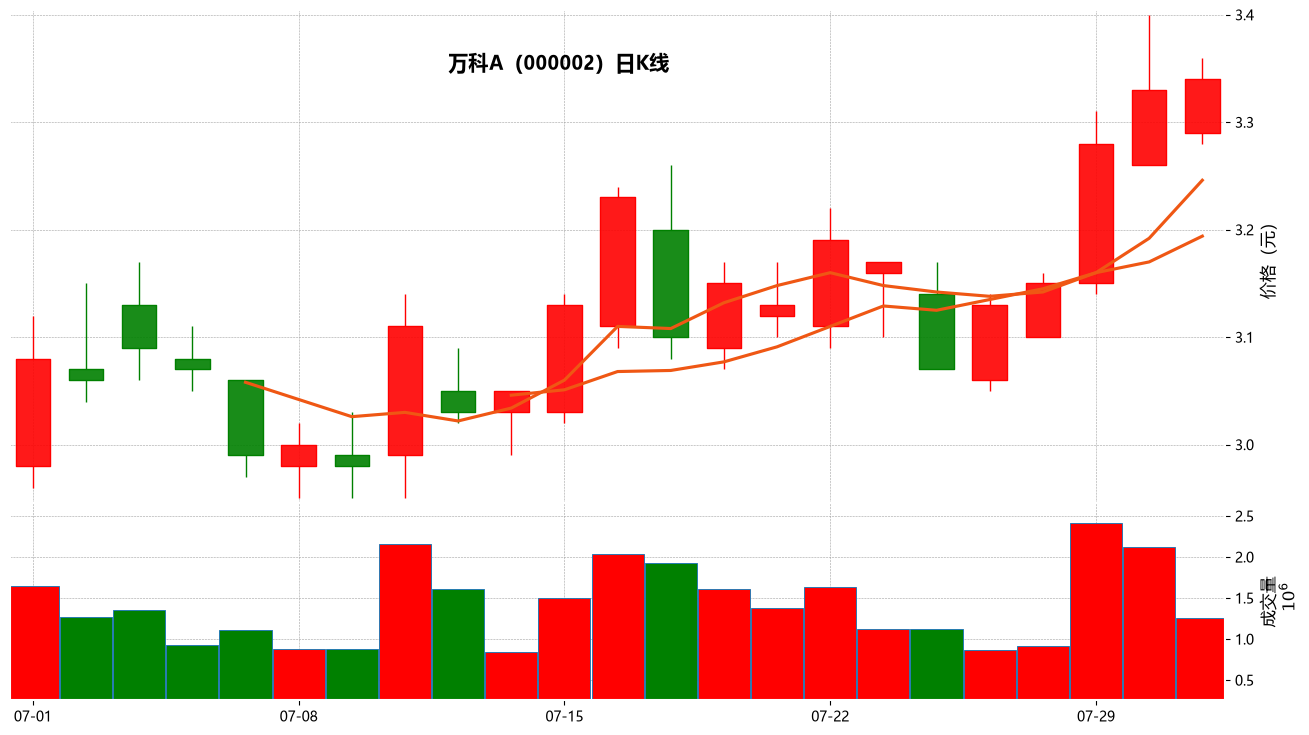

In [21]:
# 1. 复制数据，避免反复执行 Notebook 时修改原始 df
plot_df = df.copy()

# 2. 腾讯接口返回的是英文小写字段
plot_df = plot_df.rename(columns={
    "date": "Date",
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "volume": "Volume",
})

# 3. 日期必须成为 DatetimeIndex
plot_df["Date"] = pd.to_datetime(plot_df["Date"])
plot_df = plot_df.set_index("Date").sort_index()

# 4. 保证 OHLCV 是数值
price_columns = ["Open", "High", "Low", "Close", "Volume"]
plot_df[price_columns] = plot_df[price_columns].apply(
    pd.to_numeric,
    errors="coerce",
)

plot_df = plot_df.dropna(subset=["Open", "High", "Low", "Close"])

# 5. A股配色：红涨绿跌
market_colors = mpf.make_marketcolors(
    up="red",
    down="green",
    edge="inherit",
    wick="inherit",
    volume="inherit",
)

# 6. 创建支持中文的 mplfinance 样式
cn_style = mpf.make_mpf_style(
    base_mpf_style="charles",
    marketcolors=market_colors,
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": ["Microsoft YaHei"],
        "axes.unicode_minus": False,
        "font.weight": "normal",
        "axes.titleweight": "normal",
        "axes.labelweight": "normal",
    },
)

# 7. 绗制K线
mpf.plot(
    plot_df,
    type="candle",
    volume=True,
    mav=(5, 10),
    title="万科A（000002）日K线",
    ylabel="价格（元）",
    ylabel_lower="成交量",
    style=cn_style,       # 不再写 style="charles"
    figsize=(14, 8),
    datetime_format="%m-%d",
    xrotation=0,
    tight_layout=True,
)

#### 指数

In [22]:
df = ak.stock_zh_index_daily(symbol="sh000001")

print('上证指数日线:', df.shape)

df

上证指数日线: (8707, 6)


,date,open,high,low,close,volume
0,1990-12-19,96.050,99.980,95.790,99.980,126000
1,1990-12-20,104.300,104.390,99.980,104.390,19700
2,1990-12-21,109.070,109.130,103.730,109.130,2800
3,1990-12-24,113.570,114.550,109.130,114.550,3200
4,1990-12-25,120.090,120.250,114.550,120.250,1500
...,...,...,...,...,...,...
8702,2026-08-13,3957.161,3968.476,3924.642,3926.965,57279367700
8703,2026-08-14,3930.022,3932.641,3903.705,3927.176,49952561300
8704,2026-08-17,3930.104,3983.507,3924.474,3982.654,48983402700
8705,2026-08-18,3979.490,3994.181,3955.601,3990.304,51123428700


### 分时与逐笔

In [23]:
df = ak.stock_zh_a_minute(symbol='sz000002')

df = df.set_index('day')

print('A股分钟行情-新浪：', df.shape)

df.tail()

A股分钟行情-新浪： (1970, 6)


,open,high,low,close,volume,amount
day,,,,,,
2026-08-20 11:03:00,3.110,3.110,3.100,3.110,495200,1539929.9661
2026-08-20 11:04:00,3.110,3.110,3.100,3.110,289300,899139.9782
2026-08-20 11:05:00,3.110,3.110,3.100,3.110,603400,1876433.9711
2026-08-20 11:06:00,3.110,3.120,3.100,3.110,2388900,7429921.8527
2026-08-20 11:07:00,3.120,3.120,3.110,3.120,254000,791997.9836


In [24]:
df = ak.stock_zh_a_tick_tx_js(symbol='sz000002')

df = df.set_index('成交时间')

print('A股逐笔成交-腾讯：', df.shape)

df.tail()

C:\Users\theTruth\Documents\projects\vibe-working\trading-topic\labs\.venv\Lib\site-packages\akshare\stock\stock_zh_a_tick_tx.py:27: UserWarning: 正在下载数据，请稍等
  warnings.warn("正在下载数据，请稍等")


A股逐笔成交-腾讯： (1367, 5)


,成交价格,价格变动,成交量,成交金额,性质
成交时间,,,,,
11:06:30,3.11,-0.01,369,114769,卖盘
11:06:33,3.11,0.00,6,1866,卖盘
11:06:36,3.11,0.00,4,1244,卖盘
11:06:39,3.12,0.01,8,2493,买盘
11:06:42,3.11,-0.01,28,8708,卖盘


In [25]:
# 限量: 单次返回指定交易日的分时数据；只能获取近期的数据，此处仅返回大单数据（成交量大于等于: 400手）
# date不能太旧
df = ak.stock_intraday_sina(symbol='sz000002', date="20260811")

df = df.set_index('ticktime')

print('日内分时-新浪：', df.shape)

df.tail()

  0%|          | 0/10 [00:00<?, ?it/s]

日内分时-新浪： (551, 6)


,symbol,name,price,volume,prev_price,kind
ticktime,,,,,,
14:56:33,sz000002,万 科Ａ,3.23,56700,3.22,U
14:56:36,sz000002,万 科Ａ,3.22,55900,3.23,D
14:56:39,sz000002,万 科Ａ,3.22,47800,3.22,D
14:56:48,sz000002,万 科Ａ,3.23,47300,3.23,U
15:00:00,sz000002,万 科Ａ,3.23,583900,3.23,U


### 估值指标

In [26]:
# 1. A股估值指标（东方财富）
df = ak.stock_value_em(symbol='000002')

df = df.set_index('数据日期')

print('估值指标:', df.shape)

df.tail()

估值指标: (2094, 12)


,当日收盘价,当日涨跌幅,总市值,流通市值,总股本,流通股本,PE(TTM),PE(静),市净率,PEG值,市现率,市销率
数据日期,,,,,,,,,,,,
2026-08-13,3.22,-3.303303,3.841688e+10,3.128853e+10,11930709471,9716935865,-0.435258,-0.433812,0.347553,0.003706,14.546238,0.171224
2026-08-14,3.13,-2.795031,3.734312e+10,3.041401e+10,11930709471,9716935865,-0.423092,-0.421687,0.337839,0.003602,14.139666,0.166438
2026-08-17,3.12,-0.319489,3.722381e+10,3.031684e+10,11930709471,9716935865,-0.421740,-0.420340,0.336760,0.003591,14.094492,0.165907
2026-08-18,3.10,-0.641026,3.698520e+10,3.012250e+10,11930709471,9716935865,-0.419037,-0.417645,0.334601,0.003568,14.004142,0.164843
2026-08-19,3.07,-0.967742,3.662728e+10,2.983099e+10,11930709471,9716935865,-0.414982,-0.413604,0.331363,0.003533,13.868619,0.163248


### 停复牌状态

In [27]:
df = ak.stock_tfp_em(date="20260801")

print('停复牌信息-东方财富:', df.shape)

df

停复牌信息-东方财富: (18, 9)


,序号,代码,名称,停牌时间,停牌截止时间,停牌期限,停牌原因,所属市场,预计复牌时间
0,0,002155,湖南黄金,2026-08-20,2026-08-26,连续停牌,刊登重要公告,深交所主板,2026-08-27
1,1,300862,蓝盾光电,2026-08-19,NaT,连续停牌,交易异常波动,深交所创业板,NaT
2,2,920059,双英集团,2026-08-19,2026-08-19,盘中停牌,交易异常波动,北京证券交易所,NaT
3,3,002906,华阳集团,2026-08-18,NaT,连续停牌,刊登重要公告,深交所主板,NaT
4,4,002084,海鸥住工,2026-08-17,NaT,连续停牌,刊登重要公告,深交所主板,NaT
5,5,002445,中南文化,2026-08-17,2026-08-21,连续停牌,刊登重要公告,深交所主板,2026-08-24
6,6,300176,鸿特科技,2026-08-13,2026-08-20,连续停牌,刊登重要公告,深交所创业板,2026-08-21
7,7,688646,逸飞激光,2026-08-12,2026-08-12,停牌一天,刊登重要公告,上交所科创板,2026-08-13
8,8,600984,建设机械,2026-08-11,NaT,连续停牌,拟筹划重大资产重组,上交所主板,NaT
9,9,603221,爱丽家居,2026-08-11,2026-08-17,连续停牌,交易异常波动,上交所主板,2026-08-18


---
## 3. `fundamentals`：公司与财务基本面

回答“这家公司经营得怎么样”。

覆盖公司所有经营数据，包括：公司资料；A股、港股、美股财务报表；财务指标；主营业务；股东持仓；盈利预测；商誉；ESG。

**本教程收录的当前可用接口：47 个**

### 可用接口汇总

| 序号 | 子类    | 接口名称                  | 接口函数                                          | 数据源  |
| -: | ----- | --------------------- | --------------------------------------------- | ---- |
|  1 | 公司资料  | 公司概况-巨潮               | `stock_profile_cninfo`                        | 巨潮资讯 |
|  2 | 公司资料  | 港股公司资料-东方财富           | `stock_hk_company_profile_em`                 | 东方财富 |
|  3 | 公司资料  | 主营构成-东方财富             | `stock_zygc_em`                               | 东方财富 |
|  4 | 公司资料  | 主营介绍-同花顺              | `stock_zyjs_ths`                              | 同花顺  |
|  5 | 财务报表  | 三大财务报表-新浪             | `stock_financial_report_sina`                 | 新浪财经 |
|  6 | 财务报表  | 港股三大财务报表-东方财富         | `stock_financial_hk_report_em`                | 东方财富 |
|  7 | 财务报表  | 美股三大财务报表-东方财富         | `stock_financial_us_report_em`                | 东方财富 |
|  8 | 财务报表  | 资产负债表-报告期-东方财富        | `stock_balance_sheet_by_report_em`            | 东方财富 |
|  9 | 财务报表  | 资产负债表-年度-东方财富         | `stock_balance_sheet_by_yearly_em`            | 东方财富 |
| 10 | 财务报表  | 已退市-资产负债表-报告期-东方财富    | `stock_balance_sheet_by_report_delisted_em`   | 东方财富 |
| 11 | 财务报表  | 资产负债表-同花顺             | `stock_financial_debt_new_ths`                | 同花顺  |
| 12 | 财务报表  | 资产负债表（旧接口）-同花顺        | `stock_financial_debt_ths`                    | 同花顺  |
| 13 | 财务报表  | 利润表-报告期-东方财富          | `stock_profit_sheet_by_report_em`             | 东方财富 |
| 14 | 财务报表  | 利润表-单季度-东方财富          | `stock_profit_sheet_by_quarterly_em`          | 东方财富 |
| 15 | 财务报表  | 利润表-年度-东方财富           | `stock_profit_sheet_by_yearly_em`             | 东方财富 |
| 16 | 财务报表  | 已退市-利润表-报告期-东方财富      | `stock_profit_sheet_by_report_delisted_em`    | 东方财富 |
| 17 | 财务报表  | 利润表-同花顺               | `stock_financial_benefit_new_ths`             | 同花顺  |
| 18 | 财务报表  | 利润表（旧接口）-同花顺          | `stock_financial_benefit_ths`                 | 同花顺  |
| 19 | 财务报表  | 现金流量表-单季度-东方财富        | `stock_cash_flow_sheet_by_quarterly_em`       | 东方财富 |
| 20 | 财务报表  | 现金流量表-报告期-东方财富        | `stock_cash_flow_sheet_by_report_em`          | 东方财富 |
| 21 | 财务报表  | 现金流量表-年度-东方财富         | `stock_cash_flow_sheet_by_yearly_em`          | 东方财富 |
| 22 | 财务报表  | 已退市-现金流量表-报告期-东方财富    | `stock_cash_flow_sheet_by_report_delisted_em` | 东方财富 |
| 23 | 财务报表  | 现金流量表-同花顺             | `stock_financial_cash_new_ths`                | 同花顺  |
| 24 | 财务报表  | 现金流量表（旧接口）-同花顺        | `stock_financial_cash_ths`                    | 同花顺  |
| 25 | 财务指标  | 关键财务指标-新浪             | `stock_financial_abstract`                    | 新浪财经 |
| 26 | 财务指标  | 财务分析指标-新浪             | `stock_financial_analysis_indicator`          | 新浪财经 |
| 27 | 财务指标  | A股主要财务指标-东方财富         | `stock_financial_analysis_indicator_em`       | 东方财富 |
| 28 | 财务指标  | 港股主要财务指标-东方财富         | `stock_financial_hk_analysis_indicator_em`    | 东方财富 |
| 29 | 财务指标  | 美股主要财务指标-东方财富         | `stock_financial_us_analysis_indicator_em`    | 东方财富 |
| 30 | 财务指标  | 港股最新财务指标-东方财富         | `stock_hk_financial_indicator_em`             | 东方财富 |
| 31 | 财务指标  | 重要财务指标-同花顺            | `stock_financial_abstract_new_ths`            | 同花顺  |
| 32 | 财务指标  | 重要财务指标（旧接口）-同花顺       | `stock_financial_abstract_ths`                | 同花顺  |
| 33 | 财务指标  | A股商誉市场概况-东方财富         | `stock_sy_profile_em`                         | 东方财富 |
| 34 | 股东持仓  | 流通股东-新浪               | `stock_circulate_stock_holder`                | 新浪财经 |
| 35 | 股东持仓  | 基金持股-新浪               | `stock_fund_stock_holder`                     | 新浪财经 |
| 36 | 股东持仓  | 主要股东-新浪               | `stock_main_stock_holder`                     | 新浪财经 |
| 37 | 股东持仓  | 股东分析-十大流通股东-东方财富      | `stock_gdfx_free_holding_teamwork_em`         | 东方财富 |
| 38 | 股东持仓  | 股东分析-股东持股分析-十大股东-东方财富 | `stock_gdfx_holding_analyse_em`               | 东方财富 |
| 39 | 股东持仓  | 股东分析-股东持股明细-十大股东-东方财富 | `stock_gdfx_holding_detail_em`                | 东方财富 |
| 40 | 股东持仓  | 股东分析-股东协同-十大股东-东方财富   | `stock_gdfx_holding_teamwork_em`              | 东方财富 |
| 41 | 股东持仓  | 股东户数-东方财富             | `stock_zh_a_gdhs`                             | 东方财富 |
| 42 | 股东持仓  | 股东户数详情-东方财富           | `stock_zh_a_gdhs_detail_em`                   | 东方财富 |
| 43 | 盈利预测  | 盈利预测-东方财富             | `stock_profit_forecast_em`                    | 东方财富 |
| 44 | 盈利预测  | 盈利预测-同花顺              | `stock_profit_forecast_ths`                   | 同花顺  |
| 45 | 盈利预测  | 港股盈利预测-经济通            | `stock_hk_profit_forecast_et`                 | 未识别  |
| 46 | ESG评价 | ESG评级-MSCI-新浪         | `stock_esg_msci_sina`                         | 新浪财经 |
| 47 | ESG评价 | ESG评级-路孚特-新浪          | `stock_esg_rft_sina`                          | 新浪财经 |


### 公司概况、主营业务

In [28]:
# 1. 个股公司概况-巨潮资讯
df = ak.stock_profile_cninfo(symbol="000002")

print('工商概况:', df.shape)

df.iloc[0]

工商概况: (1, 26)


公司名称                                           万科企业股份有限公司
英文名称                                China Vanke Co., Ltd.
曾用简称                                                 None
A股代码                                               000002
A股简称                                                万  科Ａ
B股代码                                                 None
B股简称                                                 None
H股代码                                                02202
H股简称                                                 万科企业
入选指数    ESG 300,国证Ａ指,沪深300,巨潮中盘,深成指R,深市精选,深证100,深证100R...
所属市场                                                深交所主板
所属行业                                                 房地产业
法人代表                                                  徐恩利
注册资金                                         1193070.9471
成立日期                                           1984-05-30
上市日期                                           1991-01-29
官方网站                                        www.vanke.com
电子邮箱          

In [29]:
df = ak.stock_zyjs_ths(symbol="000002")

print('主营业务:', df.shape)

df

主营业务: (1, 5)


,股票代码,主营业务,产品类型,产品名称,经营范围
0,000002,房地产开发和物业服务。,商品住宅,商品住宅,兴办实业(具体项目另行申报)；国内商业；物资供销业(不含专营、专控、专卖商品)；进出口业务(...


In [30]:
df = ak.stock_zygc_em(symbol="sz000002")

print('主营构成:', df.shape)

df.head()

主营构成: (200, 11)


,股票代码,报告日期,分类类型,主营构成,主营收入,收入比例,主营成本,成本比例,主营利润,利润比例,毛利率
0,000002,2025-12-31,按行业分类,房地产开发及相关资产经营业务,1.906512e+11,0.816728,1.741788e+11,0.824136,1.647234e+10,0.745845,0.086400
1,000002,2025-12-31,按行业分类,物业服务,3.552451e+10,0.152183,3.113891e+10,0.147335,4.385601e+09,0.198574,0.123453
2,000002,2025-12-31,按行业分类,其他(补充),7.257101e+09,0.031089,6.029567e+09,0.028529,1.227535e+09,0.055581,0.169149
3,000002,2025-12-31,按地区分类,上海区域,6.288068e+10,0.269374,NaN,NaN,NaN,NaN,NaN
4,000002,2025-12-31,按地区分类,其他主营业务,4.801407e+10,0.205687,2.053177e+11,0.971471,2.085794e+10,0.944419,NaN


### 三大财务报表

In [31]:
# 1. 单次获取指定报表的所有年份数据的历史数据
# symbol="现金流量表"; choice of {"资产负债表", "利润表", "现金流量表"}

df = ak.stock_financial_report_sina(stock='sz000002', symbol="资产负债表")

print('关键指标:', df.shape)

print(df.columns)

df.head(5)

关键指标: (115, 147)
Index(['报告日', '流动资产', '货币资金', '结算备付金', '拆出资金', '交易性金融资产', '买入返售金融资产', '衍生金融资产',
       '应收票据及应收账款', '应收票据',
       ...
       '归属于母公司股东权益合计', '少数股东权益', '所有者权益(或股东权益)合计', '负债和所有者权益(或股东权益)总计', '数据源',
       '是否审计', '公告日期', '币种', '类型', '更新日期'],
      dtype='str', length=147)


,报告日,流动资产,货币资金,结算备付金,拆出资金,交易性金融资产,买入返售金融资产,衍生金融资产,应收票据及应收账款,应收票据,...,归属于母公司股东权益合计,少数股东权益,所有者权益(或股东权益)合计,负债和所有者权益(或股东权益)总计,数据源,是否审计,公告日期,币种,类型,更新日期
0,20260331,NaN,60492624678.93,NaN,NaN,67090770.98,NaN,NaN,10648362166.18,6281646.51,...,110535199285.199997,117526785408.419998,228061984693.619995,997406724022.049927,定期报告,未审计,20260430,CNY,合并期末,2026-04-29T20:24:04
1,20251231,NaN,67240949734.900002,NaN,NaN,68016700.87,NaN,NaN,9521445910.26,2370899.21,...,116905224808.460007,118954833228.229996,235860058036.690002,1020622831532.859985,定期报告,是,20260430,CNY,合并期末,2026-03-31T20:06:13
2,20250930,NaN,65677132971.18,NaN,NaN,16987125.05,NaN,NaN,9596955519.809999,8551631.82,...,175755829577.720001,125274243001.460007,301030072579.180054,1136594565755.290039,定期报告,未审计,20251031,CNY,合并期末,2025-10-30T20:08:10
3,20250630,NaN,74002263778.729996,NaN,NaN,13864659.16,NaN,NaN,9340119833.059999,27960933.51,...,191440815716.190002,129719727244.869995,321160542961.059998,1194148874774.550049,定期报告,未审计,20250823,CNY,合并期末,2025-08-22T20:08:05
4,20250331,NaN,75501915435.039993,NaN,NaN,16896775.47,NaN,NaN,9215986830.559999,30620368.21,...,196728878701.040009,133245534134.210007,329974412835.25,1244039386215.600098,定期报告,未审计,20250430,CNY,合并期末,2025-04-29T20:42:08


#### 资产负债表

In [32]:
# 1. 同花顺资产负债表
df = ak.stock_financial_debt_new_ths(symbol="000002", indicator="按年度")

print('资产负债表:', df.shape)

print(df['report_name'].unique())
print(df['quarter_name'].unique())
print(df['metric_name'].unique())

df.head(5)

资产负债表: (4165, 10)
<StringArray>
['2025年报', '2024年报', '2023年报', '2022年报', '2021年报', '2020年报', '2019年报',
 '2018年报', '2017年报', '2016年报', '2015年报', '2014年报', '2013年报', '2012年报',
 '2011年报', '2010年报', '2009年报', '2008年报', '2007年报', '2006年报', '2005年报',
 '2004年报', '2003年报', '2002年报', '2001年报', '2000年报', '1999年报', '1998年报',
 '1997年报', '1996年报', '1995年报', '1994年报', '1993年报', '1992年报', '1991年报']
Length: 35, dtype: str
<StringArray>
['2025四季度', '2024四季度', '2023四季度', '2022四季度', '2021四季度', '2020四季度', '2019四季度',
 '2018四季度', '2017四季度', '2016四季度', '2015四季度', '2014四季度', '2013四季度', '2012四季度',
 '2011四季度', '2010四季度', '2009四季度', '2008四季度', '2007四季度', '2006四季度', '2005四季度',
 '2004四季度', '2003四季度', '2002四季度', '2001四季度', '2000四季度', '1999四季度', '1998四季度',
 '1997四季度', '1996四季度', '1995四季度', '1994四季度', '1993四季度', '1992四季度', '1991四季度']
Length: 35, dtype: str
<StringArray>
[                          'treasury_stock',
             'productive_biological_assets',
                        'deferred_tax_debt',
              

,report_date,report_name,report_period,quarter_name,metric_name,value,single,yoy,mom,single_yoy
0,2025-12-31,2025年报,2025-4,2025四季度,treasury_stock,,,,,
1,2025-12-31,2025年报,2025-4,2025四季度,productive_biological_assets,216117733.5300,,-0.14878916,,
2,2025-12-31,2025年报,2025-4,2025四季度,deferred_tax_debt,4697757860.4900,,-0.12170587,,
3,2025-12-31,2025年报,2025-4,2025四季度,other_payable_total,133735785207.2500,,-0.12199084,,
4,2025-12-31,2025年报,2025-4,2025四季度,equity,11930709471.0000,,0.00000000,,


#### 利润表

In [33]:
# 1. 同花顺利润表
df = ak.stock_financial_benefit_new_ths(symbol="000002", indicator="按年度")

print('利润表:', df.shape)

print(df['metric_name'].unique())

df.head(5)

利润表: (1734, 10)
<StringArray>
[                            'profit_total',
                          'exchange_income',
                   'non_operating_expenses',
                          'premiums_earned',
                'net_exposure_hedge_income',
                                  'payouts',
            'minority_comprehensive_income',
                   'operating_income_total',
                               'manage_fee',
                    'asset_disposal_income',
                    'continuing_net_profit',
                            'invest_income',
                             'other_income',
 'financial_assets_measured_amortized_cost',
                                'basic_eps',
        'parent_other_comprehensive_income',
                          'surrender_money',
                  'dividend_payment_policy',
             'operating_cost_total_special',
                         'operating_profit',
                  'associate_invest_income',
             'charges_com

,report_date,report_name,report_period,quarter_name,metric_name,value,single,yoy,mom,single_yoy
0,2025-12-31,2025年报,2025-4,2025四季度,profit_total,-73923814314.9700,,-0.56662862,,
1,2025-12-31,2025年报,2025-4,2025四季度,exchange_income,,,,,
2,2025-12-31,2025年报,2025-4,2025四季度,non_operating_expenses,3688680011.6800,,0.48816955,,
3,2025-12-31,2025年报,2025-4,2025四季度,premiums_earned,,,,,
4,2025-12-31,2025年报,2025-4,2025四季度,net_exposure_hedge_income,,,,,


#### 现金流量表

In [34]:
# 1. 同花顺现金流量
df = ak.stock_financial_cash_new_ths(symbol="000002", indicator="按年度")

print('利润表:', df.shape)

print(df['metric_name'].unique())

df.head(5)

利润表: (2520, 10)
<StringArray>
[                 'financing_cash_inflow_special',
                      'invest_cash_outflow_total',
               'pay_other_related_financing_cash',
                                  'pay_debt_cash',
                   'financing_cash_outflow_total',
                'subsidiary_pay_holder_dividends',
 'dispose_fixed_intangible_long_term_assets_loss',
                'deposits_and_funds_net_addition',
          'cash_equivalents_net_addition_special',
                  'repurchase_funds_net_addition',
           'pay_interest_fee_and_commission_cash',
                           'received_invest_cash',
                 'received_origin_insurance_cash',
                     'receive_issuance_bond_cash',
                      'borrow_other_net_addition',
             'pay_origin_insurance_contract_cash',
 'disposal_financial_assets_measure_net_addition',
                    'financing_cash_inflow_total',
                                'investment_loss',
 

,report_date,report_name,report_period,quarter_name,metric_name,value,single,yoy,mom,single_yoy
0,2025-12-31,2025年报,2025-4,2025四季度,financing_cash_inflow_special,,,,,
1,2025-12-31,2025年报,2025-4,2025四季度,invest_cash_outflow_total,5843412573.1500,622438114.2600,-0.34188911,-0.76413723,-0.73816726
2,2025-12-31,2025年报,2025-4,2025四季度,pay_other_related_financing_cash,2218317875.6000,499882276.6800,-0.16140627,-0.13482872,-0.40279521
3,2025-12-31,2025年报,2025-4,2025四季度,pay_debt_cash,56603589457.0300,6821945387.4300,-0.28368289,-0.49779401,-0.29116108
4,2025-12-31,2025年报,2025-4,2025四季度,financing_cash_outflow_total,74959012705.6300,9727562112.7600,-0.29260229,-0.48179937,-0.30595283


### 财务指标

In [35]:
# 单次获取指定 symbol 和 start_year 的所有财务指标历史数据

df = ak.stock_financial_analysis_indicator(symbol="000002", start_year="2020")

print('财务指标:', df.shape)
print('财务指标:', df.columns)

df.head(5)

  0%|          | 0/7 [00:00<?, ?it/s]

财务指标: (25, 86)
财务指标: Index(['日期', '摊薄每股收益(元)', '加权每股收益(元)', '每股收益_调整后(元)', '扣除非经常性损益后的每股收益(元)',
       '每股净资产_调整前(元)', '每股净资产_调整后(元)', '每股经营性现金流(元)', '每股资本公积金(元)',
       '每股未分配利润(元)', '调整后的每股净资产(元)', '总资产利润率(%)', '主营业务利润率(%)', '总资产净利润率(%)',
       '成本费用利润率(%)', '营业利润率(%)', '主营业务成本率(%)', '销售净利率(%)', '股本报酬率(%)',
       '净资产报酬率(%)', '资产报酬率(%)', '销售毛利率(%)', '三项费用比重', '非主营比重', '主营利润比重',
       '股息发放率(%)', '投资收益率(%)', '主营业务利润(元)', '净资产收益率(%)', '加权净资产收益率(%)',
       '扣除非经常性损益后的净利润(元)', '主营业务收入增长率(%)', '净利润增长率(%)', '净资产增长率(%)',
       '总资产增长率(%)', '应收账款周转率(次)', '应收账款周转天数(天)', '存货周转天数(天)', '存货周转率(次)',
       '固定资产周转率(次)', '总资产周转率(次)', '总资产周转天数(天)', '流动资产周转率(次)', '流动资产周转天数(天)',
       '股东权益周转率(次)', '流动比率', '速动比率', '现金比率(%)', '利息支付倍数', '长期债务与营运资金比率(%)',
       '股东权益比率(%)', '长期负债比率(%)', '股东权益与固定资产比率(%)', '负债与所有者权益比率(%)',
       '长期资产与长期资金比率(%)', '资本化比率(%)', '固定资产净值率(%)', '资本固定化比率(%)', '产权比率(%)',
       '清算价值比率(%)', '固定资产比重(%)', '资产负债率(%)', '总资产(元)', '经营现金净流量对销售收入比率(%)',
       '资产的经营现金流量回报率(%)', 

,日期,摊薄每股收益(元),加权每股收益(元),每股收益_调整后(元),扣除非经常性损益后的每股收益(元),每股净资产_调整前(元),每股净资产_调整后(元),每股经营性现金流(元),每股资本公积金(元),每股未分配利润(元),...,2-3年以内应收帐款(元),3年以内应收帐款(元),1年以内预付货款(元),1-2年以内预付货款(元),2-3年以内预付货款(元),3年以内预付货款(元),1年以内其它应收款(元),1-2年以内其它应收款(元),2-3年以内其它应收款(元),3年以内其它应收款(元)
0,2020-03-31,0.2150,0.1110,0.1110,NaN,24.2530,16.6928,-0.2614,1.0918,8.5472,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-06-30,1.6035,1.1100,1.1100,1.07,25.0700,16.8400,1.9458,1.6572,8.2674,...,NaN,NaN,NaN,1.669637e+10,2.301901e+10,NaN,NaN,5.929571e+10,3.605168e+10,NaN
2,2020-09-30,2.5884,1.7410,1.7410,NaN,26.0500,17.4453,2.8733,1.6145,8.9005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-12-31,5.1041,3.6200,3.6200,3.51,30.1130,19.3200,4.5782,1.5971,8.4713,...,NaN,NaN,NaN,2.141890e+09,3.744288e+09,NaN,NaN,5.093053e+10,3.237831e+10,NaN
4,2021-03-31,0.2158,0.1112,0.1112,NaN,30.5939,19.4279,1.4529,1.5877,8.5825,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 股东持仓

In [36]:
# 1. 流通股东（新浪）
df = ak.stock_circulate_stock_holder(symbol='sz000002')

print('流通股东:', df.shape)

df.head(5)

  0%|          | 0/90 [00:00<?, ?it/s]

流通股东: (895, 7)


,截止日期,公告日期,编号,股东名称,持股数量,占流通股比例,股本性质
0,2026-03-31,2026-04-30,1,深铁集团,3242810791,27.197,国有股
1,2026-03-31,2026-04-30,2,HKSCC NOMINEES LIMITED,2206363864,18.504,境外法人股
2,2026-03-31,2026-04-30,3,中央汇金资产管理有限责任公司,185478200,1.556,国有股
3,2026-03-31,2026-04-30,4,香港中央结算有限公司,147049855,1.233,境外法人股
4,2026-03-31,2026-04-30,5,中国工商银行股份有限公司-南方中证全指房地产交易型开放式指数证券投资基金,81997589,0.688,境内法人股


In [37]:
# 2. 基金持股（新浪）
df = ak.stock_fund_stock_holder(symbol='sz000002')

print('流通股东:', df.shape)

df.head(5)

  0%|          | 0/7 [00:00<?, ?it/s]

流通股东: (993, 7)


,基金名称,基金代码,持仓数量,占流通股比例,持股市值,占净值比例,截止日期
0,招商沪深300地产等权重指数C,013273,103786318,0.8699,307207000.0,34.14,2026-06-30
1,南方中证全指房地产ETF,512200,53557589,0.4489,158530000.0,5.03,2026-06-30
2,华宝中证800地产ETF,159707,25711781,0.2155,76106900.0,15.65,2026-06-30
3,房地产ETF,159768,17581479,0.1474,52041200.0,15.59,2026-06-30
4,鹏华中证800地产指数(LOF)A,160628,8540887,0.0716,25281000.0,15.01,2026-06-30


In [38]:
# 3. 主要股东-新浪
df = ak.stock_main_stock_holder(stock='000002')

print('主要股东:', df.shape)

df.head(5)

主要股东: (1118, 10)


,编号,股东名称,持股数量,持股比例,股本性质,截至日期,公告日期,股东说明,股东总数,平均持股数
0,1,深圳市地铁集团有限公司,3.242811e+09,27.18,流通A股,2026-03-31,2026-04-30,NaN,489869.0,24355.0
1,2,HKSCC NOMINEES LIMITED,2.206364e+09,18.49,流通H股,2026-03-31,2026-04-30,NaN,489869.0,24355.0
2,3,中央汇金资产管理有限责任公司,1.854782e+08,1.55,流通A股,2026-03-31,2026-04-30,NaN,489869.0,24355.0
3,4,香港中央结算有限公司,NaN,NaN,流通A股,2026-03-31,2026-04-30,NaN,489869.0,24355.0
4,5,中国工商银行股份有限公司-南方中证全指房地产交易型开放式指数证券投资基金,NaN,NaN,流通A股,2026-03-31,2026-04-30,NaN,489869.0,24355.0


### 盈利预测

In [39]:
# 盈利预测-同花顺
df = ak.stock_profit_forecast_ths(symbol='000002')

print('盈利预测-同花顺:', df.shape)

df.head(5)

盈利预测-同花顺: (3, 6)


,年度,预测机构数,最小值,均值,最大值,行业平均数
0,2026,5,-3.43,-2.24,-1.44,0.20
1,2027,5,-2.34,-1.50,-1.00,0.36
2,2028,4,-1.51,-0.90,0.02,0.46


In [40]:
# 盈利预测-东方财富
df = ak.stock_profit_forecast_em()

print('盈利预测-同花顺:', df.shape)

df.head(5)

  0%|          | 0/6 [00:00<?, ?it/s]

盈利预测-同花顺: (2834, 13)


,序号,代码,名称,研报数,机构投资评级(近六个月)-买入,机构投资评级(近六个月)-增持,机构投资评级(近六个月)-中性,机构投资评级(近六个月)-减持,机构投资评级(近六个月)-卖出,2025预测每股收益,2026预测每股收益,2027预测每股收益,2028预测每股收益
0,1,600519,贵州茅台,46,37.0,9.0,0.0,0.0,0.0,65.851755,68.002766,71.957660,75.465581
1,2,605499,东鹏饮料,42,28.0,14.0,0.0,0.0,0.0,6.013712,7.630095,8.807952,9.947150
2,3,300750,宁德时代,40,33.0,7.0,0.0,0.0,0.0,15.605504,20.764077,25.874641,31.044895
3,4,603345,安井食品,39,31.0,8.0,0.0,0.0,0.0,4.078255,5.334897,6.049949,6.744486
4,5,600600,青岛啤酒,35,24.0,11.0,0.0,0.0,0.0,3.363229,3.534571,3.730286,3.925588


### ESG评级

In [41]:
# ESG评级-MSCI-新浪
df = ak.stock_esg_rft_sina()

print('ESG评级-路孚特-新浪:', df.shape)

df.head(5)

ESG评级-路孚特-新浪: (100, 13)


,股票代码,ESG评分,ESG评分日期,环境总评,环境总评日期,社会责任总评,社会责任总评日期,治理总评,治理总评日期,争议总评,争议总评日期,行业,交易所
0,WW,27.1(C-),2026-08-15,1.3(D-),2026-07-04,31.0(C-),2026-08-15,45.1(C+),2026-08-15,100.0(A+),2026-06-06,其他消费服务,纳斯达克
1,NLY,58.4(B),2026-08-15,42.9(C+),2026-08-15,53.3(B-),2026-08-15,81.3(A-),2026-08-15,100.0(A+),2026-06-06,房地产投资信托,纽交所
2,RBB,28.2(C-),2026-08-15,5.9(D-),2026-08-15,20.8(D+),2026-08-15,47.2(C+),2026-08-15,100.0(A+),2026-04-04,区域银行,纳斯达克
3,CLX,77.1(A-),2026-08-15,78.2(A-),2026-08-08,76.4(A-),2026-08-08,77.4(A-),2026-08-15,40.7(C),2026-08-15,家庭-个人护理,纽交所
4,002195.SZ,24.4(D+),2026-08-15,0.0(D-),2026-05-25,15.2(D),2026-08-15,39.7(C),2026-08-15,100.0(A+),2026-05-23,IT服务Ⅱ,深交所


---
## 4. `corporate_actions`：公司行为与股本事件

回答“持有人的权益发生了什么”。涵盖发行、分红、回购、解禁、质押和股本变化。

| 行为   | 钱从哪里来/到哪里去    | 股本变化 | 对老股东的核心影响         |
| ---- | ------------- | ---: | ----------------- |
| 增发   | 新投资者向公司投入资金   |   增加 | 可能被稀释，公司获得融资      |
| 配股   | 原股东按持股比例向公司缴款 |   增加 | 不参与通常会被稀释         |
| 股份回购 | 公司拿现金买回自己的股票  | 通常减少 | 剩余股东持股比例、每股指标可能提高 |
| 现金分红 | 公司把现金分给股东     |   不变 | 股东收到现金，公司净资产减少    |
| 送股   | 未分配利润转为股本     |   增加 | 股数增加，但总价值不会凭空增加   |
| 转增股本 | 资本公积转为股本      |   增加 | 与送股类似，主要区别是会计来源不同 |


**本教程收录的当前可用接口：24 个**

### 可用接口汇总

| 序号 | 子类      | 接口名称          | 接口函数                                  | 数据源   |
| -: | ------- | ------------- | ------------------------------------- | ----- |
|  1 | 分红送转    | 分红送配详情-东方财富   | `stock_fhps_detail_em`                | 东方财富  |
|  2 | 分红送转    | 分红情况-同花顺      | `stock_fhps_detail_ths`               | 同花顺   |
|  3 | 分红送转    | 港股分红派息-东方财富   | `stock_hk_dividend_payout_em`         | 东方财富  |
|  4 | 分红送转    | 港股分红派息-同花顺    | `stock_hk_fhpx_detail_ths`            | 同花顺   |
|  5 | 分红送转    | 历史分红-巨潮       | `stock_dividend_cninfo`               | 巨潮资讯  |
|  6 | 分红送转    | 历史分红-新浪       | `stock_history_dividend`              | 新浪财经  |
|  7 | 分红送转    | 分红配股-新浪       | `stock_history_dividend_detail`       | 新浪财经  |
|  8 | 分红送转    | 分红派息提醒-百度     | `news_trade_notify_dividend_baidu`    | 百度股市通 |
|  9 | 增发配股    | 全部增发-东方财富     | `stock_qbzf_em`                       | 东方财富  |
| 10 | 增发配股    | 增发-新浪         | `stock_add_stock`                     | 新浪财经  |
| 11 | 股份回购    | 股票回购-东方财富     | `stock_repurchase_em`                 | 东方财富  |
| 12 | 股份回购    | A股股本结构-东方财富   | `stock_zh_a_gbjg_em`                  | 东方财富  |
| 13 | 股份回购    | 股本变动-巨潮       | `stock_hold_change_cninfo`            | 巨潮资讯  |
| 14 | 限售解禁    | 限售解禁详情-东方财富   | `stock_restricted_release_detail_em`  | 东方财富  |
| 15 | 限售解禁    | 限售解禁批次-东方财富   | `stock_restricted_release_queue_em`   | 东方财富  |
| 16 | 限售解禁    | 限售解禁汇总-东方财富   | `stock_restricted_release_summary_em` | 东方财富  |
| 17 | 限售解禁    | 限售解禁-新浪       | `stock_restricted_release_queue_sina` | 新浪财经  |
| 18 | 股权质押    | 股权质押市场概况-东方财富 | `stock_gpzy_profile_em`               | 东方财富  |
| 19 | 高管及股东变动 | 险资举牌-同花顺      | `stock_rank_xzjp_ths`                 | 同花顺   |
| 20 | 高管及股东变动 | 实际控制人持股变动-巨潮  | `stock_hold_control_cninfo`           | 巨潮资讯  |
| 21 | 高管及股东变动 | 高管持股变动明细-巨潮   | `stock_hold_management_detail_cninfo` | 巨潮资讯  |
| 22 | 高管及股东变动 | 高管增减持明细-东方财富  | `stock_hold_management_person_em`     | 东方财富  |
| 23 | 高管及股东变动 | 内部交易-雪球       | `stock_inner_trade_xq`                | 雪球    |
| 24 | 高管及股东变动 | 股东大会-东方财富     | `stock_gddh_em`                       | 东方财富  |


### 分红送转

In [42]:
df_div = ak.stock_fhps_detail_em(symbol='600036')

print('分红送配详情-东方财富：', df_div.shape)

df_div.tail()

  0%|          | 0/1 [00:00<?, ?it/s]

分红送配详情-东方财富： (26, 19)


,报告期,业绩披露日期,送转股份-送转总比例,送转股份-送股比例,送转股份-转股比例,现金分红-现金分红比例,现金分红-现金分红比例描述,现金分红-股息率,每股收益,每股净资产,每股公积金,每股未分配利润,净利润同比增长,总股本,预案公告日,股权登记日,除权除息日,方案进度,最新公告日期
21,2023-12-31,2024-03-26,NaN,NaN,NaN,19.72,"10派19.72元(含税,扣税后17.748元)",0.056863,5.63,36.71,2.594449,22.536558,6.224096,25219845601,2024-03-26,2024-07-10,2024-07-11,实施分配,2024-07-04
22,2024-12-31,2025-03-26,NaN,NaN,NaN,20.00,"10派20.00元(含税,扣税后18.00元)",0.041459,5.66,41.46,2.594330,25.141872,1.220311,25219845601,2025-03-26,2025-07-10,2025-07-11,实施分配,2025-07-04
23,2025-06-30,2025-12-30,NaN,NaN,NaN,10.13,"10派10.13元(含税,扣税后9.117元)",0.025256,2.89,42.10,2.593973,26.021689,0.250191,25219845601,2025-08-30,2026-01-15,2026-01-16,实施分配,2026-01-10
24,2025-12-31,2026-03-28,NaN,NaN,NaN,10.03,10派10.03元(含税),0.026711,5.70,43.43,2.593537,26.955115,1.206273,25219845601,2026-03-28,2026-07-09,2026-07-10,实施分配,2026-07-04
25,2026-06-30,2026-03-28,NaN,NaN,NaN,NaN,现金分红金额占2026年半年度归属于本行普通股股东净利润的比例为35%,NaN,NaN,NaN,NaN,NaN,NaN,25219845601,2026-08-29,NaT,NaT,预披露,2026-03-28


In [43]:
df_div = ak.stock_fhps_detail_ths(symbol='600036')

print('分红情况-同花顺：', df_div.shape)

df_div.tail()

分红情况-同花顺： (51, 11)


,报告期,董事会日期,股东大会预案公告日期,实施公告日,分红方案说明,A股股权登记日,A股除权除息日,AH分红总额,方案进度,股利支付率,税前分红率
46,2024中报,2024-08-30,NaT,NaT,不分配不转增,NaT,NaT,--,董事会预案,--,--
47,2024年报,2025-03-26,2025-06-26,2025-07-04,10派20元(含税),2025-07-10,2025-07-11,504.40亿,实施方案,35.34%,4.15%
48,2025中报,2025-12-30,NaT,2026-01-10,10派10.13元(含税),2026-01-15,2026-01-16,255.48亿,实施方案,35.05%,2.53%
49,2025年报,2026-03-28,2026-06-26,2026-07-04,10派10.030元(含税),2026-07-09,2026-07-10,252.96亿,实施方案,17.6%,--
50,2026中报,2026-03-28,2026-06-26,NaT,分红金额占2026年半年度归属于本行普通股股东净利润的比例为35%,NaT,NaT,--,股东大会预案,--,--


In [44]:
df_div = ak.stock_dividend_cninfo(symbol='600036')

print('历史分红-巨潮：', df_div.shape)

df_div.tail()

历史分红-巨潮： (27, 11)


,实施方案公告日期,分红类型,送股比例,转增比例,派息比例,股权登记日,除权日,派息日,股份到账日,实施方案分红说明,报告时间
22,2023-07-06,年度分红,NaN,NaN,17.38,2023-07-12,2023-07-13,2023-07-13,NaN,10派17.38元(含税),2022年报
23,2024-07-04,年度分红,NaN,NaN,19.72,2024-07-10,2024-07-11,2024-07-11,NaN,10派19.72元(含税),2023年报
24,2025-07-04,年度分红,NaN,NaN,20.00,2025-07-10,2025-07-11,2025-07-11,NaN,10派20元(含税),2024年报
25,2026-01-10,中期分红,NaN,NaN,10.13,2026-01-15,2026-01-16,2026-01-16,NaN,10派10.13元(含税),2025半年报
26,2026-07-04,年度分红,NaN,NaN,10.03,2026-07-09,2026-07-10,2026-07-10,NaN,10派10.03元(含税),2025年报


### 增发配股

In [45]:
df_div = ak.stock_history_dividend_detail(symbol='600036')

print('分红配股-新浪：', df_div.shape)

df_div.head()

分红配股-新浪： (28, 8)


,公告日期,送股,转增,派息,进度,除权除息日,股权登记日,红股上市日
0,2026-07-04,0,0.0,10.03,实施,2026-07-10,2026-07-09,NaT
1,2026-01-10,0,0.0,10.13,实施,2026-01-16,2026-01-15,NaT
2,2025-12-30,0,0.0,10.13,预案,NaT,NaT,NaT
3,2025-07-04,0,0.0,20.00,实施,2025-07-11,2025-07-10,NaT
4,2024-07-04,0,0.0,19.72,实施,2024-07-11,2024-07-10,NaT


In [46]:
df_repurchase = ak.stock_qbzf_em()

print('全部增发-东方财富:', df_repurchase.shape)

df_repurchase.head()

  0%|          | 0/12 [00:00<?, ?it/s]

全部增发-东方财富: (5853, 11)


,股票代码,股票简称,增发代码,发行方式,发行总数,网上发行,发行价格,最新价,发行日期,增发上市日期,锁定期
0,920059,双英集团,None,公开增发,38021560,32318326.0,11.13,18.59,2026-08-10,2026-08-19,0.5年
1,920107,恒兴股份,None,公开增发,20970000,18873000.0,16.02,21.77,2026-08-05,2026-08-17,1年
2,603161,科华控股,None,定向增发,29753648,NaN,10.96,15.56,2026-08-03,2026-08-07,3年
3,920138,杰理科技,None,公开增发,33000000,29700000.0,18.86,39.22,2026-08-03,2026-08-12,0.5-1年
4,688206,概伦电子,None,定向增发,67456798,NaN,17.42,39.41,2026-07-31,2026-08-13,1-2年


### 股份回购

In [47]:
df = ak.stock_repurchase_em()

print('股票回购-东方财富:', df.shape)

df.head()

股票回购-东方财富: (5473, 18)


,序号,股票代码,股票简称,最新价,计划回购价格区间,计划回购数量区间-下限,计划回购数量区间-上限,占公告前一日总股本比例-下限,占公告前一日总股本比例-上限,计划回购金额区间-下限,计划回购金额区间-上限,回购起始时间,实施进度,已回购股份价格区间-下限,已回购股份价格区间-上限,已回购股份数量,已回购金额,最新公告日期
0,1,600276,恒瑞医药,52.66,81.78,12227900.0,24455900.0,0.184233,0.368467,1.000000e+09,2.000000e+09,2026-08-19,董事会预案,NaN,NaN,NaN,NaN,2026-08-20
1,2,688018,乐鑫科技,110.83,135.00,740700.0,1481500.0,0.316019,0.632082,5.209480e+07,5.209480e+07,2026-08-18,实施中,109.47,111.25,470995.0,52094802.20,2026-08-20
2,3,688100,威胜信息,26.10,43.00,3488400.0,4651200.0,0.709478,0.945971,3.887893e+07,3.887893e+07,2026-08-17,实施中,25.43,26.15,1500000.0,38878929.74,2026-08-20
3,4,601616,广电电气,3.71,4.20,23809500.0,47619000.0,2.789058,5.578116,6.617730e+07,6.617730e+07,2026-07-29,实施中,3.62,3.85,17808500.0,66177300.00,2026-08-05
4,5,300001,特锐德,36.14,50.00,6000000.0,12000000.0,0.568544,1.137088,8.433089e+07,8.433089e+07,2026-07-29,实施中,36.00,36.98,2324700.0,84330891.00,2026-08-20


### 限售股解禁

In [48]:
# 1. 限售股解禁详情
df_release = ak.stock_restricted_release_detail_em(start_date='20260101', end_date='20260630')

print('限售解禁:', df_release.shape)

df_release.tail()

限售解禁: (736, 12)


,序号,股票代码,股票简称,解禁时间,限售股类型,解禁数量,实际解禁数量,实际解禁市值,占解禁前流通市值比例,解禁前一交易日收盘价,解禁前20日涨跌幅,解禁后20日涨跌幅
731,732,301105,鸿铭股份,2026-06-30,"首发原股东限售股份,追加承诺限售股份上市流通",33562503.0,3375001.0,1.450575e+08,0.170347,42.98,-18.829707,-2.383864
732,733,001369,双欣材料,2026-06-30,首发机构配售股份,6424045.0,6424045.0,8.685309e+07,0.030966,13.52,-7.813571,-6.319703
733,734,301448,开创电气,2026-06-30,首发原股东限售股份,56160000.0,22600500.0,1.025611e+09,0.318842,45.38,33.915575,-9.717391
734,735,600789,鲁抗医药,2026-06-30,定向增发机构配售股份,111628565.0,111628565.0,7.601905e+08,0.110491,6.81,-5.837563,-0.386407
735,736,688582,芯动联科,2026-06-30,首发原股东限售股份,151520000.0,151520000.0,9.848800e+09,0.377160,65.00,23.634497,-37.419033


### 险资举牌

In [49]:
df = ak.stock_rank_xzjp_ths()

print('险资举牌:', df.shape)

df.tail()

险资举牌: (36, 12)


,序号,举牌公告日,股票代码,股票简称,现价,涨跌幅,举牌方,增持数量,交易均价,增持数量占总股本比例,变动后持股总数,变动后持股比例
31,32,2026-04-24,300295,*ST三六五,11.61,0.43,谢恺,948.07万,9.90,5.00,948.07万,5.00
32,33,2026-03-28,603358,华达科技,45.77,0.15,张耀坤,619.51万,28.62,1.32,2814.71万,5.99
33,34,2026-03-18,300201,海伦哲,14.51,1.11,上海顶航慧恒企业咨询合伙企业(有限合伙),1306.69万,9.09,1.30,7458.73万,7.39
34,35,2026-03-12,000932,华菱钢铁,3.59,0.28,信泰人寿保险股份有限公司,4650.00万,5.95,0.68,5.46亿,7.97
35,36,2026-03-04,600846,同济科技,11.90,-0.34,上海杨浦商贸(集团)有限公司,536.35万,13.06,0.86,5675.72万,9.08


In [50]:
df = ak.stock_inner_trade_xq()

print('内部交易-雪球：', df.shape)

df.tail()

内部交易-雪球： (24919, 9)


,股票代码,股票名称,变动日期,变动人,变动股数,成交均价,变动后持股数,与董监高关系,董监高职务
24914,SH603421,鼎信通讯,2025-01-02,陈萍,1000,6.77,13488645.0,本人,高级管理人员
24915,SH603366,日出东方,2025-01-02,孙命阳,-20200,12.43,60800.0,NaN,NaN
24916,SH601611,中国核建,2025-01-02,丁淑英,-4600,8.60,100000.0,NaN,NaN
24917,SH600850,电科数字,2025-01-02,邢懋腾,4108,17.33,19108.0,本人,高级管理人员
24918,SH600328,中盐化工,2025-01-02,周杰,20000,8.05,161570.0,本人,董事


---
## 5. `sector`：行业、概念与市场结构

回答“公司处于哪个行业，行业整体表现如何”。涵盖行业/概念分类、行情、估值与中观指标。

**本教程收录的当前可用接口：23 个**

### 可用接口汇总

| 序号 | 子类      | 接口名称            | 接口函数                                 | 数据源  |
| -: | ------- | --------------- | ------------------------------------ | ---- |
|  1 | 板块分类    | 概念板块简介-同花顺      | `stock_board_concept_info_ths`       | 同花顺  |
|  2 | 板块分类    | 概念板块列表-同花顺      | `stock_board_concept_name_ths`       | 同花顺  |
|  3 | 板块分类    | 行业板块简介-同花顺      | `stock_board_industry_info_ths`      | 同花顺  |
|  4 | 板块分类    | 行业板块列表-同花顺      | `stock_board_industry_name_ths`      | 同花顺  |
|  5 | 板块分类    | 行业分类-巨潮         | `stock_industry_category_cninfo`     | 巨潮资讯 |
|  6 | 板块分类    | 申万行业分类          | `stock_industry_clf_hist_sw`         | 未识别  |
|  7 | 板块行情    | 概念板块行情-同花顺      | `stock_board_concept_summary_ths`    | 同花顺  |
|  8 | 板块行情    | 行业板块行情-同花顺      | `stock_board_industry_summary_ths`   | 同花顺  |
|  9 | 板块行情    | 行业板块行情-新浪       | `stock_sector_spot`                  | 新浪财经 |
| 10 | 板块行情    | 行业板块成分详情-新浪     | `stock_sector_detail`                | 新浪财经 |
| 11 | 板块行情    | 行业市盈率-巨潮        | `stock_industry_pe_ratio_cninfo`     | 巨潮资讯 |
| 12 | 板块行情    | A股破净统计-乐咕       | `stock_a_below_net_asset_statistics` | 乐咕乐股 |
| 13 | 板块行情    | 市场创新高/低数量-乐咕    | `stock_a_high_low_statistics`        | 乐咕乐股 |
| 14 | 行业资金与结构 | 行业股权质押比例-东方财富   | `stock_gpzy_industry_data_em`        | 东方财富 |
| 15 | 行业资金与结构 | 概念资金流-同花顺       | `stock_fund_flow_concept`            | 同花顺  |
| 16 | 行业资金与结构 | 行业资金流-同花顺       | `stock_fund_flow_industry`           | 同花顺  |
| 17 | 同业比较    | A股同行杜邦分析对比-东方财富 | `stock_zh_dupont_comparison_em`      | 东方财富 |
| 18 | 同业比较    | A股同行成长性对比-东方财富  | `stock_zh_growth_comparison_em`      | 东方财富 |
| 19 | 同业比较    | A股同行规模对比-东方财富   | `stock_zh_scale_comparison_em`       | 东方财富 |
| 20 | 同业比较    | A股同行估值对比-东方财富   | `stock_zh_valuation_comparison_em`   | 东方财富 |
| 21 | 同业比较    | 港股同行成长性对比-东方财富  | `stock_hk_growth_comparison_em`      | 东方财富 |
| 22 | 同业比较    | 港股同行规模对比-东方财富   | `stock_hk_scale_comparison_em`       | 东方财富 |
| 23 | 同业比较    | 港股同行估值对比-东方财富   | `stock_hk_valuation_comparison_em`    | 东方财富 |

### 板块分类

直接调用 AKShare 接口获取行业板块列表；这里只观察原始返回，不进行再封装。

In [51]:
df = ak.stock_board_concept_name_ths()

print('概念板块列表-同花顺：', df.shape)

df.head()

  0%|          | 0/39 [00:00<?, ?it/s]

概念板块列表-同花顺： (375, 2)


,name,code
0,阿尔茨海默概念,308614
1,AI PC,309121
2,AI手机,309120
3,AI语料,309126
4,阿里巴巴概念,301558


In [52]:
df = ak.stock_board_industry_name_ths()

print('行业板块列表-同花顺：', df.shape)

df.head()

行业板块列表-同花顺： (90, 2)


,name,code
0,半导体,881121
1,白酒,881273
2,白色家电,881131
3,保险,881156
4,包装印刷,881138


In [53]:
df = ak.stock_industry_category_cninfo()

print('行业分类-巨潮：', df.shape)

df.head()

行业分类-巨潮： (294, 8)


,类目编码,类目名称,终止日期,行业类型,行业类型编码,类目名称英文,父类编码,分级
0,Z,巨潮行业分类标准,NaT,巨潮行业分类标准,008002,CNINF Industry Classification Standard,008,0
1,Z01,能源,NaT,巨潮行业分类标准,008002,Energy,Z,1
2,Z0101,能源,NaT,巨潮行业分类标准,008002,Energy,Z01,2
3,Z010101,能源设备与服务,NaT,巨潮行业分类标准,008002,Energy Equipment and Services,Z0101,3
4,Z01010101,能源设备,NaT,巨潮行业分类标准,008002,Energy Equipment,Z010101,4


### 板块行情

In [54]:
df = ak.stock_board_concept_summary_ths()

print('概念板块行情-同花顺：', df.shape)

df.head()

  0%|          | 0/39 [00:00<?, ?it/s]

概念板块行情-同花顺： (50, 5)


,日期,概念名称,驱动事件,龙头股,成分股数量
0,2026-07-31,MLCC概念,MLCC概念走高，火炬电子涨停,--,35
1,2026-07-01,玻璃基板,瑞丰光电澄清与彩虹股份玻璃基板业务差异,--,56
2,2026-06-29,2026中报预增,2026中报预增板块大幅高开,--,510
3,2026-04-02,2026一季报预增,概念新服|新建“2026一季报预增”概念指数,--,101
4,2026-01-12,AI应用,昆仑万维2026上半年营收53.59亿同比增43.55% AI原生平台加速商业化,--,532


In [55]:
df = ak.stock_board_industry_summary_ths()

print('行业板块行情-同花顺：', df.shape)

df.head()

  0%|          | 0/2 [00:00<?, ?it/s]

行业板块行情-同花顺： (90, 12)


,序号,板块,涨跌幅,总成交量,总成交额,净流入,上涨家数,下跌家数,均价,领涨股,领涨股-最新价,领涨股-涨跌幅
0,1,生物制品,10.04,1035.14,226.58,-4.49,55,0,21.88,三元基因,24.76,29.97
1,2,医疗服务,6.74,1437.70,419.91,30.17,56,0,29.21,和元生物,8.10,20.00
2,3,贵金属,6.19,1130.47,335.87,23.86,13,0,29.71,兴业银锡,39.56,10.01
3,4,医疗器械,4.88,886.21,199.10,18.93,136,3,22.46,华大智造,69.11,20.00
4,5,化学制药,4.56,3564.54,582.75,25.85,146,11,16.35,键凯科技,89.45,20.00


In [56]:
# indicator="新浪行业"; choice of {"新浪行业", "启明星行业", "概念", "地域", "行业"}
df = ak.stock_sector_spot(indicator="新浪行业")

print('行业板块行情-新浪：', df.shape)

df.head()

行业板块行情-新浪： (49, 13)


,label,板块,公司家数,平均价格,涨跌额,涨跌幅,总成交量,总成交额,股票代码,个股-涨跌幅,个股-当前价,个股-涨跌额,股票名称
0,new_blhy,玻璃行业,19,16.673684,0.263158,1.603592,282801132,6733123816,sz300093,3.774,23.65,0.86,金刚光伏
1,new_cbzz,船舶制造,8,13.287143,0.072857,0.551351,85972062,1557216323,sh600685,1.075,25.38,0.27,中船防务
2,new_cmyl,传媒娱乐,40,7.603889,0.112500,1.501724,392464184,2865273483,sz300291,8.282,5.23,0.40,百纳千成
3,new_dlhy,电力行业,62,8.221333,0.016667,0.203136,1419108132,11519895686,sh600396,3.224,15.05,0.47,华电辽能
4,new_dqhy,电器行业,58,15.744815,0.018333,0.116576,621599356,9079920291,sh603988,10.016,21.20,1.93,中电电机


In [59]:
# symbol="全部A股"; choice of {"全部A股", "沪深300", "上证50", "中证500"}
df = ak.stock_a_below_net_asset_statistics(symbol="沪深300")

print('指数历史行情-新浪：', df.shape)

df.tail()

指数历史行情-新浪： (5185, 4)


,date,below_net_asset,total_company,below_net_asset_ratio
5180,2026-08-13,63,300,0.2100
5181,2026-08-14,63,300,0.2100
5182,2026-08-17,62,300,0.2067
5183,2026-08-18,62,300,0.2067
5184,2026-08-19,63,300,0.2100


In [60]:
# symbol="all"; {"all": "全部A股", "sz50": "上证50", "hs300": "沪深300", "zz500": "中证500"}
df = ak.stock_a_high_low_statistics(symbol="sz50")

print('市场创新高/低数量-乐咕：', df.shape)

df.tail()

市场创新高/低数量-乐咕： (500, 8)


,date,close,high20,low20,high60,low60,high120,low120
495,2026-08-13,2928.12,1,3,1,0,1,0
496,2026-08-14,2916.13,1,10,1,2,0,2
497,2026-08-17,2945.41,4,7,3,2,1,2
498,2026-08-18,2940.70,3,8,2,2,1,2
499,2026-08-19,2895.57,3,10,2,2,1,2


### 行业资金与结构

In [61]:
# symbol="即时"; choice of {“即时”, "3日排行", "5日排行", "10日排行", "20日排行"}
df = ak.stock_fund_flow_concept(symbol="5日排行")

print('概念资金流-同花顺：', df.shape)

df.tail()

  0%|          | 0/8 [00:00<?, ?it/s]

概念资金流-同花顺： (387, 8)


,序号,行业,公司家数,行业指数,阶段涨跌幅,流入资金,流出资金,净额
382,383,AI视频,57,2000.43,-5.96%,180.81,210.88,-30.08
383,384,小红书概念,55,1418.13,-6.13%,237.89,254.50,-16.61
384,385,Web3.0,65,1664.10,-6.30%,153.62,175.20,-21.59
385,386,兵装重组概念,14,1075.22,-6.83%,6.94,9.72,-2.78
386,387,快手概念,52,1814.14,-7.16%,203.75,225.02,-21.27


In [62]:
# symbol="即时"; choice of {“即时”, "3日排行", "5日排行", "10日排行", "20日排行"}
df = ak.stock_fund_flow_industry(symbol="10日排行")

print('行业资金流-同花顺：', df.shape)

df.tail()

  0%|          | 0/2 [00:00<?, ?it/s]

行业资金流-同花顺： (90, 8)


,序号,行业,公司家数,行业指数,阶段涨跌幅,流入资金,流出资金,净额
85,86,保险,5,1940.02,-4.71%,23.59,33.46,-9.88
86,87,影视院线,20,1241.69,-5.14%,18.14,25.47,-7.33
87,88,IT服务,129,11677.20,-5.36%,239.20,257.28,-18.09
88,89,游戏,24,9040.38,-5.49%,46.46,72.51,-26.05
89,90,汽车整车,23,2496.63,-5.59%,34.90,57.54,-22.64


### 同业比较

In [63]:
df = ak.stock_zh_scale_comparison_em(symbol="SH600036")

print('A股同行规模对比-东方财富：', df.shape)

df

A股同行规模对比-东方财富： (1, 10)


,代码,简称,总市值,总市值排名,流通市值,流通市值排名,营业收入,营业收入排名,净利润,净利润排名
0,600036,招商银行,9.873570e+11,5,8076.23,4,86940000000,6,38048000000,5


In [64]:
df = ak.stock_zh_valuation_comparison_em(symbol="SZ000002")

print('A股同行估值对比-东方财富：', df.shape)

df

A股同行估值对比-东方财富： (8, 20)


,排名,代码,简称,PEG,市盈率-TTM,市盈率-25E,市盈率-26E,市盈率-27E,市销率-24A,市销率-TTM,市销率-25E,市销率-26E,市销率-27E,市净率-24A,市净率-MRQ,市现率1-24A,市现率1-TTM,市现率2-24A,市现率2-TTM,EV/EBITDA-24A
0,63.0/90,000002,万科A,-0.005412,-0.414982,-1.167813,-1.846282,-3.398400,0.156907,0.163248,0.204687,0.250397,0.283039,0.313307,0.331363,-37.067459,13.868619,-1.628702,-2.295028,-14.891602
1,NaN,行业中值,行业中值,0.107628,-1.359003,18.858885,20.059018,19.026161,1.829170,1.999951,0.766014,1.131623,1.173055,0.895385,0.914309,4.858008,5.339036,-4.580549,-3.861014,16.738498
2,NaN,行业平均,行业平均,-0.202944,35.586159,21.775789,112.313836,38.714104,4.217456,4.561489,3.110388,2.557685,2.388349,1.412136,1.483644,8.495797,13.182394,-372.723634,-12.538224,62.028162
3,1.0,600064,南京高科,0.219475,7.470119,6.071926,5.386106,4.812112,3.857329,4.448495,3.444407,3.155484,2.924518,0.690347,0.667751,13.447140,11.849472,54.693536,-102.844124,16.695220
4,2.0,600663,陆家嘴,0.421894,31.266965,22.930537,19.975389,24.287212,2.613662,2.414215,2.194222,1.980376,2.245997,1.890069,1.861351,4.539808,4.265593,14.004153,17.422933,30.961779
5,3.0,601155,新城控股,0.461373,36.361186,27.414570,20.142647,16.700884,0.471449,0.494007,0.651765,0.788772,0.862595,0.405733,0.403699,17.541090,16.771667,-11.797374,169.312579,38.871209
6,4.0,000036,华联控股,0.482831,60.529945,59.188033,29.183865,28.190583,8.809416,7.328288,9.045672,2.870945,2.835263,1.069945,1.064528,19.172862,15.205724,28.716260,18.661652,51.204101
7,5.0,002244,滨江集团,0.708476,14.973524,12.022975,11.252185,10.959723,0.352482,0.400938,0.397999,0.426828,0.462740,0.991270,0.964776,-6.808856,164.815908,-4.453273,-6.775134,25.865042


### 行业个股

In [65]:
# 申万一级行业“银行”的指数代码
df = ak.index_component_sw(symbol="801780")

print("股票数量:", len(df))
df.head(10)

股票数量: 42


,序号,证券代码,证券名称,最新权重,计入日期
0,1,002142,宁波银行,4.3483,2021-12-13
1,2,002807,江阴银行,0.3419,2021-12-13
2,3,002839,张家港行,0.3229,2021-12-13
3,4,002936,郑州银行,0.3442,2021-12-13
4,5,002948,青岛银行,0.4089,2021-12-13
5,6,002958,青农商行,0.4121,2021-12-13
6,7,002966,苏州银行,1.0382,2021-12-13
7,8,600000,浦发银行,3.4185,2021-12-13
8,9,600015,华夏银行,1.1823,2021-12-13
9,10,600016,民生银行,2.4877,2021-12-13


---
## 6. `primary_market`：一级市场 IPO

回答“资金和交易行为发生了什么”。涵盖资金流、两融、北向、龙虎榜、大宗、涨停与情绪。

**本教程收录的当前可用接口：17 个**

### 可用接口汇总

| 序号 | 子类    | 接口名称              | 接口函数                    | 数据源  |
| -: | ----- | ----------------- | ----------------------- | ---- |
|  1 | IPO审核 | IPO辅导信息-东方财富      | `stock_ipo_tutor_em`    | 东方财富 |
|  2 | IPO审核 | 首发申报企业-东方财富       | `stock_ipo_declare_em`  | 东方财富 |
|  3 | IPO审核 | 新股上会信息-东方财富       | `stock_ipo_review_em`   | 东方财富 |
|  4 | IPO审核 | IPO审核信息-全部-东方财富   | `stock_register_all_em` | 东方财富 |
|  5 | IPO审核 | IPO审核信息-北交所-东方财富  | `stock_register_bj`     | 东方财富 |
|  6 | IPO审核 | IPO审核信息-创业板-东方财富  | `stock_register_cyb`    | 东方财富 |
|  7 | IPO审核 | 注册制审核达标企业-东方财富    | `stock_register_db`     | 东方财富 |
|  8 | IPO审核 | IPO审核信息-科创板-东方财富  | `stock_register_kcb`    | 东方财富 |
|  9 | IPO审核 | IPO审核信息-上海主板-东方财富 | `stock_register_sh`     | 东方财富 |
| 10 | IPO审核 | IPO审核信息-深圳主板-东方财富 | `stock_register_sz`     | 东方财富 |
| 11 | 新股发行  | 新股发行-巨潮           | `stock_new_ipo_cninfo`  | 巨潮资讯 |
| 12 | 新股发行  | 新股发行详情-新浪         | `stock_ipo_info`        | 新浪财经 |
| 13 | 申购中签  | 新股申购与中签-东方财富      | `stock_xgsglb_em`       | 东方财富 |
| 14 | 申购中签  | 新股申购与中签-同花顺       | `stock_ipo_ths`         | 同花顺  |
| 15 | 申购中签  | 港股新股申购与中签-同花顺     | `stock_ipo_hk_ths`      | 同花顺  |
| 16 | 上市表现  | 打新收益率-东方财富        | `stock_dxsyl_em`        | 东方财富 |
| 17 | 上市表现  | 新股上市首日表现-同花顺      | `stock_xgsr_ths`        | 同花顺  |


### IPO审核

In [66]:
df = ak.stock_register_all_em()

print('IPO审核信息-全部-东方财富：', df.shape)

df.head()

  0%|          | 0/9 [00:00<?, ?it/s]

IPO审核信息-全部-东方财富： (4399, 12)


,序号,企业名称,最新状态,注册地,行业,保荐机构,律师事务所,会计师事务所,更新日期,受理日期,拟上市地点,招股说明书
0,1,北京前景无忧电子科技股份有限公司,已问询,北京市 丰台区,计算机、通信和其他电子设备制造业,开源证券股份有限公司,北京海润天睿律师事务所,公证天业会计师事务所(特殊普通合伙),2026-08-19,2026-05-06,北交所,https://pdf.dfcfw.com/pdf/H2_AN202605061821992...
1,2,广东钶锐锶数控技术股份有限公司,提交注册,广东,通用设备制造业,国泰海通证券股份有限公司,广东华商律师事务所,天健会计师事务所(特殊普通合伙),2026-08-19,2025-06-27,科创板,https://pdf.dfcfw.com/pdf/H2_AN202606291826553...
2,3,德阳天元重工股份有限公司,提交注册,四川省 德阳市,金属制品业,第一创业证券承销保荐有限责任公司,北京市中伦律师事务所,信永中和会计师事务所(特殊普通合伙),2026-08-18,2025-12-30,北交所,https://pdf.dfcfw.com/pdf/H2_AN202608181828113...
3,4,郑州新世纪数码科技股份有限公司,注册,河南省 郑州市,专用设备制造业,东方证券股份有限公司,上海市锦天城律师事务所,立信会计师事务所(特殊普通合伙),2026-08-14,2025-06-30,北交所,https://pdf.dfcfw.com/pdf/H2_AN202606181823669...
4,5,成都德芯数字科技股份有限公司,终止,四川省 成都市,计算机、通信和其他电子设备制造业,广发证券股份有限公司,国浩律师(成都)事务所,立信会计师事务所(特殊普通合伙),2026-08-14,2024-06-28,北交所,https://pdf.dfcfw.com/pdf/H2_AN202406281637032...


### 新股发行

In [67]:
df = ak.stock_new_ipo_cninfo()

print('新股发行-巨潮：', df.shape)

df.head()

新股发行-巨潮： (403, 13)


,证劵代码,证券简称,上市日期,申购日期,发行价,总发行数量,发行市盈率,上网发行中签率,摇号结果公告日,中签公告日,中签缴款日,网上申购上限,上网发行数量
0,301688,格林生物,NaT,2026-08-20,26.33,3333.3334,19.80,NaN,2026-08-24,2026-08-21,2026-08-24,0.70,700.00
1,301689,电科思仪,NaT,2026-08-28,NaN,10206.9432,NaN,NaN,2026-09-01,2026-08-31,2026-09-01,NaN,1224.80
2,301697,贝特利,NaT,2026-08-19,12.10,6570.0000,27.39,0.016463,2026-08-21,2026-08-20,2026-08-21,1.35,2306.15
3,301699,洛轴股份,NaT,2026-08-26,NaN,12400.0000,NaN,NaN,2026-08-28,2026-08-27,2026-08-28,NaN,1488.00
4,601123,马矿股份,NaT,2026-08-21,6.65,12350.0000,13.81,NaN,2026-08-25,2026-08-24,2026-08-25,2.95,2964.00


In [68]:
df = ak.stock_ipo_info(stock='000002')

print('新股发行详情-新浪：', df.shape)

df.head()

新股发行详情-新浪： (17, 2)


,item,value
0,上市地,深圳证券交易所
1,主承销商,--
2,承销方式,其他
3,上市推荐人,"国泰君安证券股份有限公司,深圳经济特区证券公司"
4,发行价(元),1.00


### 申购中签

In [69]:
# symbol="全部A股"; choice of {"全部A股", "沪市主板", "深市主板", "创业板", "科创板", "京市主板"}
df = ak.stock_ipo_ths(symbol='科创板')

print('新股申购与中签-同花顺：', df.shape)

df.head()

新股申购与中签-同花顺： (50, 18)


,股票代码,股票简称,申购代码,发行总数（万股）,网上发行（万股）,申购上限（万股）,顶格申购需配市值（万元）,发行价格,发行市盈率,行业市盈率,申购日期,中签率（%）,中签号,中签缴款日期,上市日期,打新收益（元）,首日最高涨幅,连板天数
0,301689,电科思仪,301689,10206.9432,1224.8,1.20,12.00,-,-,61.85,08-28 周五,-,09-01电科思仪 网上定价发行摇号中签结果输入起始配号+查询恭喜! 您的配号中了中签结果以...,09-01,-,-,-,-
1,603448,天博智能,732448,3000,960,0.95,9.50,-,-,22.79,08-26 周三,-,08-28天博智能 网上定价发行摇号中签结果输入起始配号+查询恭喜! 您的配号中了中签结果以...,08-28,-,-,-,-
2,301699,洛轴股份,301699,12400,1488,1.45,14.50,-,-,38.05,08-26 周三,-,08-28洛轴股份 网上定价发行摇号中签结果输入起始配号+查询恭喜! 您的配号中了中签结果以...,08-28,-,-,-,-
3,601123,马矿股份,780123,12350,2964,2.95,29.50,6.65,13.81,36.10,08-21 周五,-,08-25马矿股份 网上定价发行摇号中签结果输入起始配号+查询恭喜! 您的配号中了中签结果以...,08-25,-,-,-,-
4,301688,格林生物,301688,3333.3334,700,0.70,7.00,26.33,19.8,28.21,08-20 周四,-,08-24格林生物 网上定价发行摇号中签结果输入起始配号+查询恭喜! 您的配号中了中签结果以...,08-24,-,-,-,-


### 上市表现

In [70]:
df = ak.stock_dxsyl_em()

print('打新收益率-东方财富：', df.shape)

df.head()

  0%|          | 0/1 [00:00<?, ?it/s]

打新收益率-东方财富： (3667, 17)


,序号,股票代码,股票简称,发行价,最新价,网上-发行中签率,网上-有效申购股数,网上-有效申购户数,网上-超额认购倍数,网下-配售中签率,网下-有效申购股数,网下-有效申购户数,网下-配售认购倍数,总发行数量,开盘溢价,首日涨幅,上市日期
0,1,301655,N绿控,8.50,36.60,0.015178,12607756.45,16932933.0,6588.67,0.014656,19584140.0,10439.0,6822.94,6834.1235,370.590000,NaN,2026-08-20
1,2,688836,C宇树-W,150.80,706.01,0.018098,5363698.65,9784646.0,5525.60,0.033418,6777780.0,11052.0,2992.38,4044.6434,629.442971,460.3448,2026-08-19
2,3,688826,C频准,186.88,945.00,0.020137,1594794.50,8109616.0,4965.89,0.020593,2380420.0,11416.0,4856.02,1000.0000,488.613014,516.4384,2026-08-18
3,4,688828,国仪公司-U,21.22,76.88,0.026570,3614056.05,6468897.0,3763.66,0.016223,13811140.0,11319.0,6164.17,4001.0000,418.378888,419.4628,2026-08-11
4,5,301717,超纯应材,65.99,378.98,0.013841,6517187.45,14672130.0,7224.86,0.016235,5758440.0,11063.0,6159.48,2546.1539,581.921503,662.2367,2026-08-11


In [71]:
df = ak.stock_xgsr_ths()

print('新股上市首日表现-同花顺：', df.shape)

df.head()

  0%|          | 0/78 [00:00<?, ?it/s]

新股上市首日表现-同花顺： (3848, 12)


,序号,股票代码,股票简称,上市日期,发行价,最新价,首日开盘价,首日收盘价,首日最高价,首日最低价,首日涨跌幅,是否破发
0,1,301655,绿控传动,2026-08-20,8.50,36.65,40.00,NaN,43.79,36.50,3.3082,否
1,2,688836,宇树科技,2026-08-19,150.80,706.00,1100.00,845.00,1100.00,800.08,4.6034,否
2,3,920059,双英集团,2026-08-19,11.13,18.41,20.88,24.75,33.50,20.85,1.2237,否
3,4,688826,频准激光,2026-08-18,186.88,945.00,1100.00,1152.00,1300.00,1100.00,5.1644,否
4,5,920107,恒兴股份,2026-08-17,16.02,21.73,29.24,30.05,36.28,29.01,0.8758,否


---
## 7. `flows_events`：资金与交易行为

回答“资金和交易行为发生了什么”。涵盖资金流、两融、北向、龙虎榜、大宗、涨停与情绪。

**本教程收录的当前可用接口：35 个**

### 可用接口汇总

| 序号 | 子类   | 接口名称             | 接口函数                             | 数据源  |
| -: | ---- | ---------------- | -------------------------------- | ---- |
|  1 | 资金流向 | 大盘资金流-东方财富       | `stock_market_fund_flow`         | 东方财富 |
|  2 | 资金流向 | 个股资金流-同花顺        | `stock_fund_flow_individual`     | 同花顺  |
|  3 | 融资融券 | 两融账户统计-东方财富      | `stock_margin_account_info`      | 东方财富 |
|  4 | 融资融券 | 融资融券标的及保证金比例     | `stock_margin_ratio_pa`          | 未识别  |
|  5 | 龙虎榜  | 龙虎榜详情-东方财富       | `stock_lhb_detail_em`            | 东方财富 |
|  6 | 龙虎榜  | 龙虎榜每日活跃营业部-东方财富  | `stock_lhb_hyyyb_em`             | 东方财富 |
|  7 | 龙虎榜  | 龙虎榜机构买卖每日统计-东方财富 | `stock_lhb_jgmmtj_em`            | 东方财富 |
|  8 | 龙虎榜  | 龙虎榜机构席位追踪-东方财富   | `stock_lhb_jgstatistic_em`       | 东方财富 |
|  9 | 龙虎榜  | 个股龙虎榜日期明细-东方财富   | `stock_lhb_stock_detail_date_em` | 东方财富 |
| 10 | 龙虎榜  | 龙虎榜个股上榜统计-东方财富   | `stock_lhb_stock_statistic_em`   | 东方财富 |
| 11 | 龙虎榜  | 龙虎榜营业部统计-东方财富    | `stock_lhb_traderstatistic_em`   | 东方财富 |
| 12 | 龙虎榜  | 龙虎榜营业部交易明细-东方财富  | `stock_lhb_yyb_detail_em`        | 东方财富 |
| 13 | 龙虎榜  | 龙虎榜营业部排行-东方财富    | `stock_lhb_yybph_em`             | 东方财富 |
| 14 | 龙虎榜  | 营业部资金实力排行-同花顺    | `stock_lh_yyb_capital`           | 同花顺  |
| 15 | 龙虎榜  | 营业部抱团操作排行-同花顺    | `stock_lh_yyb_control`           | 同花顺  |
| 16 | 龙虎榜  | 营业部上榜次数排行-同花顺    | `stock_lh_yyb_most`              | 同花顺  |
| 17 | 龙虎榜  | 龙虎榜每日详情-新浪       | `stock_lhb_detail_daily_sina`    | 新浪财经 |
| 18 | 龙虎榜  | 龙虎榜个股上榜统计-新浪     | `stock_lhb_ggtj_sina`            | 新浪财经 |
| 19 | 龙虎榜  | 龙虎榜机构席位成交明细-新浪   | `stock_lhb_jgmx_sina`            | 新浪财经 |
| 20 | 龙虎榜  | 龙虎榜机构席位追踪-新浪     | `stock_lhb_jgzz_sina`            | 新浪财经 |
| 21 | 龙虎榜  | 龙虎榜营业部上榜统计-新浪    | `stock_lhb_yytj_sina`            | 新浪财经 |
| 22 | 大宗交易 | 大宗交易活跃A股统计-东方财富  | `stock_dzjy_hygtj`               | 东方财富 |
| 23 | 大宗交易 | 大宗交易活跃营业部统计-东方财富 | `stock_dzjy_hyyybtj`             | 东方财富 |
| 24 | 大宗交易 | 大宗交易市场统计-东方财富    | `stock_dzjy_sctj`                | 东方财富 |
| 25 | 大宗交易 | 大宗交易营业部排行-东方财富   | `stock_dzjy_yybph`               | 东方财富 |
| 26 | 技术信号 | 技术选股-创新低-同花顺     | `stock_rank_cxd_ths`             | 同花顺  |
| 27 | 技术信号 | 技术选股-持续放量-同花顺    | `stock_rank_cxfl_ths`            | 同花顺  |
| 28 | 技术信号 | 技术选股-创新高-同花顺     | `stock_rank_cxg_ths`             | 同花顺  |
| 29 | 技术信号 | 技术选股-持续缩量-同花顺    | `stock_rank_cxsl_ths`            | 同花顺  |
| 30 | 技术信号 | 技术选股-量价齐跌-同花顺    | `stock_rank_ljqd_ths`            | 同花顺  |
| 31 | 技术信号 | 技术选股-量价齐升-同花顺    | `stock_rank_ljqs_ths`            | 同花顺  |
| 32 | 技术信号 | 技术选股-连续上涨-同花顺    | `stock_rank_lxsz_ths`            | 同花顺  |
| 33 | 技术信号 | 技术选股-连续下跌-同花顺    | `stock_rank_lxxd_ths`            | 同花顺  |
| 34 | 技术信号 | 技术选股-向上突破-同花顺    | `stock_rank_xstp_ths`            | 同花顺  |
| 35 | 技术信号 | 技术选股-向下突破-同花顺    | `stock_rank_xxtp_ths`            | 同花顺  |


### 资金流向

In [72]:
# symbol="即时"; choice of {“即时”, "3日排行", "5日排行", "10日排行", "20日排行"}
df = ak.stock_fund_flow_individual(symbol="3日排行")

print('个股资金流-同花顺：', df.shape)

df.head()

  0%|          | 0/105 [00:00<?, ?it/s]

个股资金流-同花顺： (5204, 7)


,序号,股票代码,股票简称,最新价,阶段涨跌幅,连续换手率,资金流入净额
0,1,688826,频准激光,934.12,399.85%,144.74%,-5.26亿
1,2,688836,宇树科技,724.89,380.70%,107.63%,-19.96亿
2,3,301655,绿控传动,36.55,330.00%,54.21%,7415.61万
3,4,600127,金健米业,8.60,33.13%,53.85%,-9.62亿
4,5,301106,骏成科技,23.36,32.35%,27.68%,-5291.94万


### 融资融券

In [73]:
df = ak.stock_margin_account_info()

print('两融账户统计-东方财富：', df.shape)

df.tail()

  0%|          | 0/7 [00:00<?, ?it/s]

两融账户统计-东方财富： (3372, 13)


,日期,融资余额,融券余额,融资买入额,融券卖出额,证券公司数量,营业部数量,个人投资者数量,机构投资者数量,参与交易的投资者数量,有融资融券负债的投资者数量,担保物总价值,平均维持担保比例
3367,2026-08-13,26497.251000,259.901348,2421.103289,12.057152,97,11666,836.4357,53375.0,502029.0,2026179.0,86956.330588,281.5776
3368,2026-08-14,26478.693099,259.866281,2008.739508,9.084817,97,11669,836.6203,53349.0,429746.0,2024313.0,87216.555710,282.5798
3369,2026-08-17,26656.525768,268.160106,2355.547651,11.503602,97,11669,836.8623,53365.0,456304.0,2028432.0,89220.539576,287.7633
3370,2026-08-18,26708.495916,270.567983,2295.517596,11.637913,97,11669,837.0774,53380.0,489340.0,2040257.0,89061.641884,286.7951
3371,2026-08-19,26411.309967,264.656065,2155.118370,14.710867,97,11670,837.2892,53407.0,446113.0,2042033.0,84790.137555,275.7790


In [74]:
df = ak.stock_margin_ratio_pa()

print('融资融券标的及保证金比例：', df.shape)

df.tail()

融资融券标的及保证金比例： (2055, 4)


,证券代码,证券简称,融资比例,融券比例
2050,301667,纳百川,1.0,1.8
2051,301668,昊创瑞通,0.8,1.5
2052,301678,新恒汇,0.8,1.5
2053,301687,新广益,1.0,1.8
2054,302132,中航成飞,0.8,1.0


### 龙虎榜

In [75]:
df = ak.stock_lhb_detail_em()

print('龙虎榜详情-东方财富：', df.shape)

df.iloc[0]

  0%|          | 0/2 [00:00<?, ?it/s]

龙虎榜详情-东方财富： (637, 21)


序号                           1
代码                      000021
名称                         深科技
上榜日                 2023-04-06
解读            1家机构买入，成功率46.03%
收盘价                       20.7
涨跌幅                     9.9894
龙虎榜净买额             85829823.97
龙虎榜买入额            488638503.98
龙虎榜卖出额            402808680.01
龙虎榜成交额            891447183.99
市场总成交额              5858168815
净买额占总成交比              1.465131
成交额占总成交比             15.217164
换手率                    18.5339
流通市值        32292355046.400002
上榜原因          日涨幅偏离值达到7%的前5只证券
上榜后1日                -1.304348
上榜后2日                -0.193237
上榜后5日                 -8.21256
上榜后10日                1.884058
Name: 0, dtype: object

In [76]:
df = ak.stock_lh_yyb_capital()

print('营业部资金实力排行-同花顺：', df.shape)

df.head(5)

  0%|          | 0/9 [00:00<?, ?it/s]

营业部资金实力排行-同花顺： (168, 7)


,序号,营业部名称,今日最高操作,今日最高金额,今日最高买入金额,累计参与金额,累计买入金额
0,1,沪股通专用,12,5.29亿,5.29亿,14.46亿,14.42亿
1,2,国泰海通证券股份有限公司上海分公司,3,4.77亿,4.77亿,6.17亿,6.17亿
2,3,东方证券股份有限公司杭州龙井路证券营业部,1,3.82亿,0.00,3.82亿,0.00
3,4,深股通专用,16,3.07亿,1.65亿,23.07亿,9.83亿
4,5,中信建投证券股份有限公司南京王府大街证...,2,1.59亿,3979.34万,2.00亿,4137.96万


### 大宗交易

In [77]:
df = ak.stock_dzjy_hygtj()

print('大宗交易活跃A股统计-东方财富：', df.shape)

df.iloc[0]

大宗交易活跃A股统计-东方财富： (1173, 16)


序号                        1
证券代码                 688097
证券简称                   博众精工
最新价                    44.1
涨跌幅                   2.107
最近上榜日            2026-08-07
上榜次数-总计                 114
上榜次数-溢价                   0
上榜次数-折价                 114
总成交额               58357.55
折溢率               -0.085547
成交总额/流通市值          2.142832
上榜日后平均涨跌幅-1日       0.362087
上榜日后平均涨跌幅-5日      -3.276643
上榜日后平均涨跌幅-10日      1.202626
上榜日后平均涨跌幅-20日    -10.665579
Name: 0, dtype: object

### 技术信号

In [78]:
df_cxfl = ak.stock_rank_cxfl_ths()

print('技术选股-持续放量-同花顺:', df_cxfl.shape)

df_cxfl.head()

  0%|          | 0/10 [00:00<?, ?it/s]

技术选股-持续放量-同花顺: (487, 10)


,序号,股票代码,股票简称,涨跌幅,最新价,成交量,基准日成交量,放量天数,阶段涨跌幅,所属行业
0,1,000407,胜利股份,-2.36,4.13,1881.89万,1063.18万(08月11日),6,0.98,燃气
1,2,601799,星宇股份,1.77,90.40,294.40万,174.39万(08月11日),6,-5.75,汽车零部件
2,3,603217,元利科技,2.51,26.53,530.18万,256.57万(08月11日),6,6.25,化学制品
3,4,688041,海光信息,-2.90,252.20,2692.20万,1223.57万(08月11日),6,-12.13,半导体
4,5,000019,深粮控股,-2.81,6.58,5456.64万,489.50万(08月12日),5,6.65,农产品加工


In [79]:
df_cxfl = ak.stock_rank_ljqs_ths()

print('技术选股-量价齐升-同花顺:', df_cxfl.shape)

df_cxfl.head()

  0%|          | 0/8 [00:00<?, ?it/s]

技术选股-量价齐升-同花顺: (371, 8)


,序号,股票代码,股票简称,最新价,量价齐升天数,阶段涨幅,累计换手率,所属行业
0,1,001277,速达股份,36.27,4,24.43,11.81,专用设备
1,2,002637,赞宇科技,12.15,4,16.94,20.48,化学制品
2,3,300821,东岳硅材,17.29,4,5.17,33.00,化学制品
3,4,603332,苏州龙杰,11.52,4,3.23,8.65,化学纤维
4,5,000020,深华发A,12.37,3,10.25,15.81,光学光电子


---
## 8. `research_disclosure`：研报、公告与资讯

回答“外部世界如何解释这家公司”。区分公告、机构研报、专业媒体、聚合新闻和投资者互动。

**本教程收录的当前可用接口：40 个**

### 可用接口汇总

| 序号 | 子类     | 接口名称           | 接口函数                                   | 数据源   |
| -: | ------ | -------------- | -------------------------------------- | ----- |
|  1 | 研报与分析师 | 分析师详情-东方财富     | `stock_analyst_detail_em`              | 东方财富  |
|  2 | 研报与分析师 | 分析师指数排名-东方财富   | `stock_analyst_rank_em`                | 东方财富  |
|  3 | 研报与分析师 | 个股研报-东方财富      | `stock_research_report_em`             | 东方财富  |
|  4 | 研报与分析师 | 科创板报告-东方财富     | `stock_zh_kcb_report_em`               | 东方财富  |
|  5 | 公告披露   | 股市日历-公司动态-东方财富 | `stock_gsrl_gsdt_em`                   | 东方财富  |
|  6 | 公告披露   | 个股公告-东方财富      | `stock_individual_notice_report`       | 东方财富  |
|  7 | 公告披露   | A股公告-东方财富      | `stock_notice_report`                  | 东方财富  |
|  8 | 公告披露   | A股信息披露公告-巨潮    | `stock_zh_a_disclosure_report_cninfo`  | 巨潮资讯  |
|  9 | 公告披露   | 互动易回答-巨潮       | `stock_irm_ans_cninfo`                 | 巨潮资讯  |
| 10 | 公告披露   | 互动易提问-巨潮       | `stock_irm_cninfo`                     | 巨潮资讯  |
| 11 | 新闻资讯   | 财经早餐-东方财富      | `stock_info_cjzc_em`                   | 东方财富  |
| 12 | 新闻资讯   | 全球财经快讯-东方财富    | `stock_info_global_em`                 | 东方财富  |
| 13 | 新闻资讯   | 全球财经直播-同花顺     | `stock_info_global_ths`                | 同花顺   |
| 14 | 新闻资讯   | 财经快讯-富途        | `stock_info_global_futu`               | 富途牛牛  |
| 15 | 新闻资讯   | 全球财经快讯-新浪      | `stock_info_global_sina`               | 新浪财经  |
| 16 | 新闻资讯   | 财新最新资讯         | `stock_news_main_cx`                   | 未识别   |
| 17 | 新闻资讯   | 财联社电报          | `stock_info_global_cls`                | 财联社   |
| 18 | 市场情绪   | 机构调研统计-东方财富    | `stock_jgdy_tj_em`                     | 东方财富  |
| 19 | 市场情绪   | 股票账户统计-东方财富    | `stock_account_statistics_em`          | 东方财富  |
| 20 | 市场情绪   | 市场参与意愿-东方财富    | `stock_comment_detail_scrd_desire_em`  | 东方财富  |
| 21 | 市场情绪   | 用户关注指数-东方财富    | `stock_comment_detail_scrd_focus_em`   | 东方财富  |
| 22 | 市场情绪   | 千股千评历史评分-东方财富  | `stock_comment_detail_zhpj_lspf_em`    | 东方财富  |
| 23 | 市场情绪   | 机构参与度-东方财富     | `stock_comment_detail_zlkp_jgcyd_em`   | 东方财富  |
| 24 | 市场情绪   | 千股千评-东方财富      | `stock_comment_em`                     | 东方财富  |
| 25 | 市场情绪   | 港股热度历史趋势-东方财富  | `stock_hk_hot_rank_detail_em`          | 东方财富  |
| 26 | 市场情绪   | 港股人气实时变动-东方财富  | `stock_hk_hot_rank_detail_realtime_em` | 东方财富  |
| 27 | 市场情绪   | 港股人气最新排名-东方财富  | `stock_hk_hot_rank_latest_em`          | 东方财富  |
| 28 | 市场情绪   | 个股热门关键词-东方财富   | `stock_hot_keyword_em`                 | 东方财富  |
| 29 | 市场情绪   | A股热度与粉丝特征-东方财富 | `stock_hot_rank_detail_em`             | 东方财富  |
| 30 | 市场情绪   | A股人气实时变动-东方财富  | `stock_hot_rank_detail_realtime_em`    | 东方财富  |
| 31 | 市场情绪   | A股人气最新排名-东方财富  | `stock_hot_rank_latest_em`             | 东方财富  |
| 32 | 市场情绪   | 人气榜相关股票-东方财富   | `stock_hot_rank_relate_em`             | 东方财富  |
| 33 | 市场情绪   | 微博舆情时间序列       | `stock_js_weibo_nlp_time`              | 未识别   |
| 34 | 市场情绪   | 微博舆情报告         | `stock_js_weibo_report`                | 未识别   |
| 35 | 市场情绪   | 大盘拥挤度-乐咕       | `stock_a_congestion_lg`                | 乐咕乐股  |
| 36 | 市场情绪   | 赚钱效应分析-乐咕      | `stock_market_activity_legu`           | 乐咕乐股  |
| 37 | 市场情绪   | 热搜股票-百度        | `stock_hot_search_baidu`               | 百度股市通 |
| 38 | 市场情绪   | 涨跌投票-百度        | `stock_zh_vote_baidu`                  | 百度股市通 |
| 39 | 市场情绪   | 股票关注排行-雪球      | `stock_hot_follow_xq`                  | 雪球    |
| 40 | 市场情绪   | 股票讨论排行-雪球      | `stock_hot_tweet_xq`                   | 雪球    |


### 个股研报

In [80]:
# 个股研报
df_report = ak.stock_research_report_em(symbol="000002")

print('个股研报:', df_report.shape)

df_report.head(5)

  0%|          | 0/3 [00:00<?, ?it/s]

个股研报: (223, 16)


,序号,股票代码,股票简称,报告名称,东财评级,机构,近一月个股研报数,2026-盈利预测-收益,2026-盈利预测-市盈率,2027-盈利预测-收益,2027-盈利预测-市盈率,2028-盈利预测-收益,2028-盈利预测-市盈率,行业,日期,报告PDF链接
0,1,000002,万科A,公司信息更新报告：业绩继续承压，关注后续股东支持与资产盘活,中性,开源证券,0,0.050,153.30,0.11,65.00,NaN,NaN,房地产开发,2025-08-27,https://pdf.dfcfw.com/pdf/H3_AP202508271735306...
1,2,000002,万科A,公司信息更新报告：销售均价有所提升，股东持续借款提供支持,中性,开源证券,0,0.050,140.70,0.11,59.70,NaN,NaN,房地产开发,2025-06-16,https://pdf.dfcfw.com/pdf/H3_AP202506161691953...
2,3,000002,万科A,短期压力犹存，持续融资及盘活存量,中性,国金证券,0,-1.277,-5.33,-0.52,-13.11,NaN,NaN,房地产开发,2025-04-30,https://pdf.dfcfw.com/pdf/H3_AP202504301664948...
3,4,000002,万科A,各方支持开展自救，风险有待化解,中性,国金证券,0,-1.277,-5.52,-0.52,-13.57,NaN,NaN,房地产开发,2025-04-01,https://pdf.dfcfw.com/pdf/H3_AP202504011649838...
4,5,000002,万科A,管理层换血，政府及深铁发声支持,中性,国金证券,0,-0.406,-17.89,NaN,NaN,NaN,NaN,房地产开发,2025-02-02,https://pdf.dfcfw.com/pdf/H3_AP202502021642724...


In [81]:
# 2. 分析师指数排行
df_analyst = ak.stock_analyst_rank_em(year='2026')

print('分析师指数排名-东方财富:', df_analyst.shape)

df_analyst.head()

  0%|          | 0/2 [00:00<?, ?it/s]

分析师指数排名-东方财富: (100, 16)


,序号,分析师名称,分析师单位,年度指数,2026年收益率,3个月收益率,6个月收益率,12个月收益率,成分股个数,2026最新个股评级-股票名称,2026最新个股评级-股票代码,分析师ID,行业代码,行业,更新日期,年度
0,1,颜枫,上海证券,4619.65,149.18,35.34,141.26,160.59,0,芯碁微装,688630,11000495635,NaN,NaN,2026-08-19,2026
1,2,方晨,上海证券,2699.19,120.58,8.52,94.75,154.39,1,鼎龙股份,300054,11000327334,610000,建筑材料,2026-08-19,2026
2,3,邱净博,广发证券,2519.33,116.28,12.34,99.81,151.93,0,长盈通,688143,11000325033,NaN,NaN,2026-08-19,2026
3,4,要文强,东北证券,4500.96,111.63,0.00,81.91,155.48,0,斯迪克,300806,11000400832,730000,通信,2026-08-19,2026
4,5,翟一梦,中邮证券,2048.43,106.83,-10.08,52.58,104.84,5,广立微,301095,11000469936,NaN,NaN,2026-08-19,2026


### 公告披露

In [82]:
df = ak.stock_individual_notice_report(security="000002")

print('个股公告:', df.shape)

df.head(5)

  0%|          | 0/31 [00:00<?, ?it/s]

个股公告: (2600, 6)


,代码,名称,公告标题,公告类型,公告日期,网址
0,000002,万科A,万科A:关于为控股子公司借款提供担保的公告,借贷,2026-08-14,https://data.eastmoney.com/notices/detail/0000...
1,000002,万科A,万科A:关于董事会会议召开日期的公告,其他,2026-08-14,https://data.eastmoney.com/notices/detail/0000...
2,000002,万科A,万科A:关于按照《香港上市规则》公布2026年7月证券变动月报表的公告,其他,2026-08-04,https://data.eastmoney.com/notices/detail/0000...
3,000002,万科A,万科A:第二十一届董事会第一次会议决议公告,高管人员任职变动,2026-08-01,https://data.eastmoney.com/notices/detail/0000...
4,000002,万科A,万科A:2026年第一次临时股东会决议公告,股东大会决议公告,2026-08-01,https://data.eastmoney.com/notices/detail/0000...


### 新闻资讯

In [83]:
df_news = ak.stock_news_main_cx()

print('财新最新资讯:', df_news.shape)

df_news.head(5)

财新最新资讯: (100, 3)


,tag,summary,url
1,市场动态,自美国与伊朗开战以来，债市延续跌势，推动长期美债收益率升至2007年以来最高,https://database.caixin.com/2026-08-20/1024759...
5,市场动态,若果真通过增发短券来替代长债，则此举就类似于财政部版的“扭转操作”,https://database.caixin.com/2026-08-20/1024759...
7,市场动态,特朗普在帖子中并未具体说明美国将采取哪些措施，伊朗已经受到美国广泛的制裁，美军也曾试图对伊朗...,https://database.caixin.com/2026-08-20/1024759...
8,市场动态,"根据CryptoQuant的数据，过去60天持仓大户增持约43,000枚比特币，按当前价格计...",https://database.caixin.com/2026-08-19/1024756...
9,市场动态,随着价格涨幅开始放缓，回购和股息可能提供下一个催化剂，并可能为股价提供支撑,https://database.caixin.com/2026-08-19/1024756...


### 市场情绪

In [84]:
# 1. 机构调研统计（东财，按日期）
df = ak.stock_jgdy_tj_em(date='20260708')

print('机构调研:', df.shape)

df.head(5)

机构调研: (1359, 11)


,序号,代码,名称,最新价,涨跌幅,接待机构数量,接待方式,接待人员,接待地点,接待日期,公告日期
0,1,002049,紫光国微,63.04,1.24,119,业绩说明会,"董事长 陈杰,副董事长、总裁 李天池,董事、副总裁 岳超,副总裁 翟应斌,财务总监 杨秋平,...",线上会议:进门财经平台,2026-08-19,2026-08-20
1,2,300776,帝尔激光,115.40,-0.22,54,电话会议,"董事、副总经理 段晓婷,董事会秘书 乔端",线上电话会议、公司会议室,2026-08-19,2026-08-20
2,3,300855,图南股份,32.98,-0.06,15,特定对象调研,"董事会秘书 何剑,证券事务代表 范路璐",公司会议室,2026-08-19,2026-08-20
3,4,300689,澄天伟业,53.57,-0.13,11,特定对象调研,"董事会秘书、财务总监 蒋伟红,证券事务代表 陈远紫",深圳市南山区粤海街道高新区社区高新南九道10号深圳湾科技生态园10栋B座34楼公司会议室,2026-08-19,2026-08-20
4,5,002981,朝阳科技,23.38,1.78,1,特定对象调研,董事会秘书 袁宏,广东朝阳电子科技股份有限公司会议室,2026-08-19,2026-08-20


## 总结

健康检查的运行结果表明，akshare 可用接口大致只有一半，并且部分接口时可用时不可用，一天之内的运行结果都不一样，说明不是包版本的问题。

遇到的坑包括：
- 深交所的股票列表接口在实验开始阶段可用，但是实验接近结束时不可用。
- 健康检查时，也发现有些接口不稳定、无法调用，或者虽然能调用，但返回的数据为空或过期（只有几年前的数据或）。
- 接口设计一致性总体较好，但也存在symbol、stock混用的情况。
- 部分接口存在风控，一会好，会议崩。

在正式实验或代码开发阶段，都建议前置一个接口健康度检查，提升可观测性，检查不仅要包括是否可调用，还有返回结果是否合乎逻辑。